# 9주차 실습 (1) — Graph Theory for Machine Learning

> **그래프는 '관계'의 자료구조입니다. 데이터에 연결이 있다면 그래프 이론이 필요합니다.**

- **Type:** Build · **Language:** Python · **Time:** ~90분
- **선수 지식:** Phase 1 Lesson 01~03 (선형대수, 행렬)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/21-graph-theory>

## 🎯 학습 목표

1. **인접 행렬·인접 리스트**를 갖춘 그래프 클래스를 만들고 **BFS·DFS**를 구현합니다.
2. **그래프 라플라시안**을 계산하고 고유값으로 **연결 성분**을 찾고 노드를 군집화합니다.
3. **GNN 메시지 패싱** 한 라운드를 정규화 인접 행렬 곱으로 구현합니다.
4. **피들러 벡터**로 그래프를 분할하는 **스펙트럴 군집화**를 적용합니다.

---

## 📖 이 노트북을 읽는 법

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 표로는 담기지 않는 데이터 |
| 1 | 그래프의 종류와 인접 행렬 |
| 2 | 차수와 차수 분포 |
| 3 | BFS와 DFS — 두 가지 탐색 |
| 4 | 🔑 그래프 라플라시안 — 스펙트럴 그래프 이론의 심장 |
| 5 | 라플라시안의 네 가지 성질 |
| 6 | 🔨 스펙트럴 군집화와 피들러 벡터 |
| 7 | 🔨 메시지 패싱 — GNN의 핵심 연산 |
| 8 | 🏭 GCN — 왜 하필 그 정규화인가 |
| 9 | 🏭 PageRank — 랜덤 워크로 중요도 재기 |
| 10 | 🏭 Karate Club 실전 분석 |
| 11 | 📝 연습문제 (풀이 포함) |
| 12 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 표로는 담기지 않는 데이터

소셜 네트워크, 분자, 지식 베이스, 인용 네트워크, 도로 지도 — 전부 그래프입니다.

전통적인 ML은 데이터를 **납작한 표**로 봅니다. 각 행이 독립이고, 각 특징이 열이죠.
**그런데 연결의 구조 자체가 중요할 때 표는 실패합니다.**

소셜 네트워크를 생각해 보세요. 어떤 사용자가 무슨 상품을 살지 예측하고 싶습니다.
그 사람의 구매 이력도 중요하지만, **친구들의 구매 이력이 더 중요합니다.**
연결이 신호를 나르고 있는 거예요.

분자도 마찬가지입니다. 단백질과 결합할지 예측하고 싶은데,
원자 자체보다 **원자들이 어떻게 결합되어 있는지**가 핵심입니다. **구조가 곧 데이터**입니다.

**GNN(Graph Neural Network)** 은 딥러닝에서 가장 빠르게 성장하는 분야입니다.
신약 개발, 소셜 추천, 사기 탐지, 지식 그래프 추론이 전부 여기서 돌아갑니다.
그리고 모든 GNN은 **같은 기초 위에** 서 있습니다.

### 🧭 필요한 것은 딱 네 가지입니다

```
1. 그래프를 행렬로 표현하기      (1절)  ← 곱셈을 하려면 행렬이어야 합니다
2. 구조를 탐색하는 알고리즘       (3절)
3. 라플라시안                    (4~6절) ← 스펙트럴 그래프 이론에서 가장 중요한 행렬
4. 메시지 패싱                   (7~8절) ← GNN을 작동시키는 연산
```

그리고 이 노트북의 큰 그림은 이렇습니다.

```
          그래프 (노드 + 엣지)
                 │
      ┌──────────┴──────────┐
      ▼                     ▼
  탐색으로 보기          행렬로 보기
  BFS / DFS (3절)      A, D, L (1,2,4절)
      │                     │
      ▼                     ▼
  연결 성분·최단거리     고유값 분해 (5절)
                            │
                 ┌──────────┴──────────┐
                 ▼                     ▼
          스펙트럴 군집화 (6절)     메시지 패싱 → GCN (7~8절)
```

**왼쪽(탐색)과 오른쪽(행렬)이 같은 답을 다른 방식으로 내놓는다**는 걸 5절에서 확인할 겁니다.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
from collections import deque, Counter

import numpy as np
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=4, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 30초 데모 — '연결'이 실제로 신호를 나르는지 확인합니다
n = 120
labels_true = np.r_[np.zeros(n//2, int), np.ones(n//2, int)]

# 커뮤니티 2개짜리 그래프: 같은 커뮤니티끼리 12%, 다른 커뮤니티끼리 1% 확률로 연결
rng_graph = np.random.default_rng(0)
A_struct = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        p = 0.12 if labels_true[i] == labels_true[j] else 0.01
        if rng_graph.random() < p:
            A_struct[i, j] = A_struct[j, i] = 1
print(f"그래프: 노드 {n}개, 평균 차수 {A_struct.sum(1).mean():.1f}, 커뮤니티 2개")

# 노드 특징은 라벨 신호(0.6)보다 노이즈(1.5)가 훨씬 큽니다 -> 특징만으로는 거의 못 맞힙니다
def make_features(seed):
    return labels_true[:, None] * 0.6 + np.random.default_rng(seed).normal(0, 1.5, (n, 1))

def best_threshold_acc(v):
    a = max((((v > t).astype(int)) == labels_true).mean()
            for t in np.linspace(v.min(), v.max(), 400))
    return max(a, 1 - a)

# 이웃 평균 = 메시지 패싱 (7절에서 제대로 다룹니다). 자기 자신도 포함시킵니다.
A_self = A_struct + np.eye(n)
A_avg = A_self / A_self.sum(1, keepdims=True)

print("\n특징을 '이웃과 섞을수록' 커뮤니티를 얼마나 잘 맞히나")
print("(특징 생성 시드 40개로 반복해 평균 낸 값입니다)\n")
print(f"{'메시지 패싱 라운드':>20}{'분류 정확도':>16}")
print("-" * 38)
acc_by_round = np.zeros(5)
for seed in range(40):
    H = make_features(seed)
    for k in range(5):
        acc_by_round[k] += best_threshold_acc(H[:, 0])
        H = A_avg @ H
acc_by_round /= 40
for k, a in enumerate(acc_by_round):
    print(f"{k:>20}{a:>15.1%}")

print(f"\n=> 노드 특징은 하나도 바꾸지 않았는데 정확도가 "
      f"{acc_by_round[0]:.0%} -> {acc_by_round[-1]:.0%}로 올랐습니다.")
print("   '이웃과 섞기'만으로요. 연결이 정보를 나르고 있다는 증거이고,")
print("   이게 GNN이 작동하는 이유입니다.")
print("\n   💡 원리는 간단합니다. 같은 커뮤니티 이웃들의 노이즈는 평균 내면 상쇄되고,")
print("      공통된 라벨 신호만 남기 때문입니다 (6주차 중심극한정리의 그래프 버전).")

# 이후 절에서 쓸 기본 특징 하나를 고정합니다
X = make_features(1)

그래프: 노드 120개, 평균 차수 7.9, 커뮤니티 2개

특징을 '이웃과 섞을수록' 커뮤니티를 얼마나 잘 맞히나
(특징 생성 시드 40개로 반복해 평균 낸 값입니다)

          메시지 패싱 라운드          분류 정확도
--------------------------------------
                   0          61.5%
                   1          72.8%
                   2          84.7%
                   3          92.0%
                   4          95.6%

=> 노드 특징은 하나도 바꾸지 않았는데 정확도가 62% -> 96%로 올랐습니다.
   '이웃과 섞기'만으로요. 연결이 정보를 나르고 있다는 증거이고,
   이게 GNN이 작동하는 이유입니다.

   💡 원리는 간단합니다. 같은 커뮤니티 이웃들의 노이즈는 평균 내면 상쇄되고,
      공통된 라벨 신호만 남기 때문입니다 (6주차 중심극한정리의 그래프 버전).


## 1️⃣ 그래프의 종류와 인접 행렬

그래프 `G = (V, E)`는 **정점(노드) `V`** 와 **엣지 `E`** 로 이루어집니다. 각 엣지가 두 노드를 잇습니다.

### 📐 두 가지 축으로 분류합니다

**방향성** — 무향 그래프에서 엣지 `(u,v)`는 `u↔v` 양쪽을 뜻합니다.
유향 그래프에서는 `u→v`만 뜻하고, 반대는 보장되지 않습니다.

**가중치** — 비가중 그래프의 엣지는 있거나 없거나 둘 중 하나입니다.
가중 그래프의 엣지에는 거리·비용·강도 같은 숫자가 붙습니다.

| 종류 | 예시 |
| --- | --- |
| 무향·비가중 | 페이스북 친구 관계 |
| 유향·비가중 | 트위터 팔로우 |
| 무향·가중 | 도로 지도 (거리) |
| 유향·가중 | 웹 링크 (PageRank) |

### 📐 인접 행렬 — 그래프를 행렬로

$$A_{ij} = \begin{cases} 1 & \text{노드 } i \to j \text{ 엣지가 있으면}\\ 0 & \text{없으면}\end{cases}$$

무향 그래프에서 `A`는 **대칭**입니다. 가중 그래프에서는 `A[i][j] =` 엣지의 가중치입니다.

```
삼각형: 노드 0,1,2 / 엣지 (0,1), (1,2), (0,2)

A = [[0, 1, 1],
     [1, 0, 1],
     [1, 1, 0]]
```

> 🔑 **인접 행렬은 모든 GNN의 입력입니다.**
> 그리고 `A`에 대한 **행렬 연산이 그래프에 대한 연산과 대응**됩니다.
> 아래에서 `A²`의 의미를 확인해 보면 이게 무슨 뜻인지 바로 보입니다.

In [3]:
class Graph:
    def __init__(self, n_nodes, directed=False):
        self.n = n_nodes
        self.directed = directed
        self.adj = {i: {} for i in range(n_nodes)}      # 인접 리스트(딕셔너리)

    def add_edge(self, u, v, weight=1.0):
        self.adj[u][v] = weight
        if not self.directed:
            self.adj[v][u] = weight

    def neighbors(self, node):
        return sorted(self.adj[node].keys())

    def degree(self, node):
        return len(self.adj[node])

    def adjacency_matrix(self):
        A = np.zeros((self.n, self.n))
        for u in range(self.n):
            for v, w in self.adj[u].items():
                A[u][v] = w
        return A

    def degree_matrix(self):
        return np.diag([self.degree(i) for i in range(self.n)])

    def laplacian(self):
        return self.degree_matrix() - self.adjacency_matrix()

# 삼각형
tri = Graph(3)
for u, v in [(0, 1), (1, 2), (0, 2)]:
    tri.add_edge(u, v)

A = tri.adjacency_matrix()
print("삼각형의 인접 행렬 A =\n", A.astype(int))
print(f"\n대칭인가? {np.array_equal(A, A.T)}  (무향 그래프이므로 대칭이어야 합니다)")
print("차수 행렬 D =\n", tri.degree_matrix().astype(int))

print("\n[🔑 A의 거듭제곱이 뜻하는 것 — 경로의 개수입니다]")
path = Graph(5)
for u, v in [(0,1), (1,2), (2,3), (3,4)]:
    path.add_edge(u, v)
Ap = path.adjacency_matrix()
print("  경로 그래프 0-1-2-3-4")
print(f"  A[0][2]   = {Ap[0,2]:.0f}   (0에서 2로 가는 '길이 1' 경로 수)")
print(f"  A²[0][2]  = {(Ap@Ap)[0,2]:.0f}   (길이 2 경로 수: 0→1→2)")
print(f"  A³[0][3]  = {(Ap@Ap@Ap)[0,3]:.0f}   (길이 3 경로 수: 0→1→2→3)")
print(f"  A²[0][4]  = {(Ap@Ap)[0,4]:.0f}   (2걸음으로는 4에 못 갑니다)")
print("\n  => A^k[i][j] = i에서 j로 가는 '길이 k' 경로의 개수입니다.")
print("     그래프 연산이 행렬 연산으로 바뀌는 첫 번째 예시입니다.")

삼각형의 인접 행렬 A =
 [[0 1 1]
 [1 0 1]
 [1 1 0]]

대칭인가? True  (무향 그래프이므로 대칭이어야 합니다)
차수 행렬 D =
 [[2 0 0]
 [0 2 0]
 [0 0 2]]

[🔑 A의 거듭제곱이 뜻하는 것 — 경로의 개수입니다]
  경로 그래프 0-1-2-3-4
  A[0][2]   = 0   (0에서 2로 가는 '길이 1' 경로 수)
  A²[0][2]  = 1   (길이 2 경로 수: 0→1→2)
  A³[0][3]  = 1   (길이 3 경로 수: 0→1→2→3)
  A²[0][4]  = 0   (2걸음으로는 4에 못 갑니다)

  => A^k[i][j] = i에서 j로 가는 '길이 k' 경로의 개수입니다.
     그래프 연산이 행렬 연산으로 바뀌는 첫 번째 예시입니다.


## 2️⃣ 차수와 차수 분포

노드의 **차수(degree)** 는 그 노드에 붙은 엣지의 개수입니다.
유향 그래프에서는 **진입 차수(in-degree)** 와 **진출 차수(out-degree)** 로 나뉩니다.

차수 행렬 `D`는 대각 행렬입니다.

$$D_{ii} = \deg(i), \qquad D_{ij} = 0 \;(i \ne j)$$

### 🔑 차수 분포가 네트워크의 성격을 드러냅니다

차수는 **노드의 중요도**를 알려줍니다. 차수가 높으면 **허브 노드**죠.
그리고 **차수의 분포**를 보면 네트워크의 종류를 알 수 있습니다.

| 네트워크 종류 | 차수 분포 | 특징 |
| --- | --- | --- |
| **소셜 네트워크** | **거듭제곱 법칙**(power law) | 소수의 거대 허브 + 다수의 말단 노드 |
| **무작위 그래프** | 푸아송 분포 | 대부분 평균 차수 근처에 몰림 |

거듭제곱 법칙은 로그-로그 그래프에서 **직선**으로 나타납니다.
아래에서 두 종류를 나란히 만들어 비교해 보겠습니다.

In [4]:
def erdos_renyi(n, p, seed=0):
    # 무작위 그래프: 모든 쌍을 확률 p로 연결
    rng = np.random.default_rng(seed)
    g = Graph(n)
    for i in range(n):
        for j in range(i+1, n):
            if rng.random() < p:
                g.add_edge(i, j)
    return g

def barabasi_albert(n, m, seed=0):
    # 선호적 연결(preferential attachment): 차수가 높은 노드에 더 붙습니다
    rng = np.random.default_rng(seed)
    g = Graph(n)
    for i in range(m):                       # 초기 완전 그래프
        for j in range(i+1, m):
            g.add_edge(i, j)
    for new in range(m, n):
        targets, pool = set(), []
        for node in range(new):
            pool += [node] * max(g.degree(node), 1)     # 차수에 비례해 뽑힐 확률
        while len(targets) < m:
            targets.add(pool[rng.integers(len(pool))])
        for t in targets:
            g.add_edge(new, t)
    return g

N = 800
g_random = erdos_renyi(N, 0.005, seed=1)
g_scale = barabasi_albert(N, 2, seed=1)

print(f"{'네트워크':<20}{'평균 차수':>12}{'최대 차수':>12}{'차수 표준편차':>16}{'최대/평균':>12}")
print("-" * 74)
degs = {}
for name, g in [("무작위 (ER)", g_random), ("선호적 연결 (BA)", g_scale)]:
    d = np.array([g.degree(i) for i in range(g.n)])
    degs[name] = d
    print(f"{name:<20}{d.mean():>12.2f}{d.max():>12}{d.std():>16.2f}{d.max()/d.mean():>12.1f}")

print("\n=> 평균 차수는 비슷한데 '최대 차수'가 완전히 다릅니다.")
print("   BA 네트워크에는 평균의 수십 배 차수를 가진 허브가 존재합니다.")
print("   이게 소셜 네트워크에서 인플루언서가 생기는 구조입니다.")

print("\n[상위 5개 노드가 차지하는 엣지 비율]")
for name, d in degs.items():
    top5 = np.sort(d)[::-1][:5].sum()
    print(f"  {name:<20}: {top5/d.sum()*100:5.1f}%")

네트워크                       평균 차수       최대 차수         차수 표준편차       최대/평균
--------------------------------------------------------------------------
무작위 (ER)                    3.88          11            1.99         2.8
선호적 연결 (BA)                 3.99          56            4.88        14.0

=> 평균 차수는 비슷한데 '최대 차수'가 완전히 다릅니다.
   BA 네트워크에는 평균의 수십 배 차수를 가진 허브가 존재합니다.
   이게 소셜 네트워크에서 인플루언서가 생기는 구조입니다.

[상위 5개 노드가 차지하는 엣지 비율]
  무작위 (ER)            :   1.7%
  선호적 연결 (BA)         :   7.1%


### 🖼️ 그림 1 — 무작위 네트워크 vs 허브가 있는 네트워크

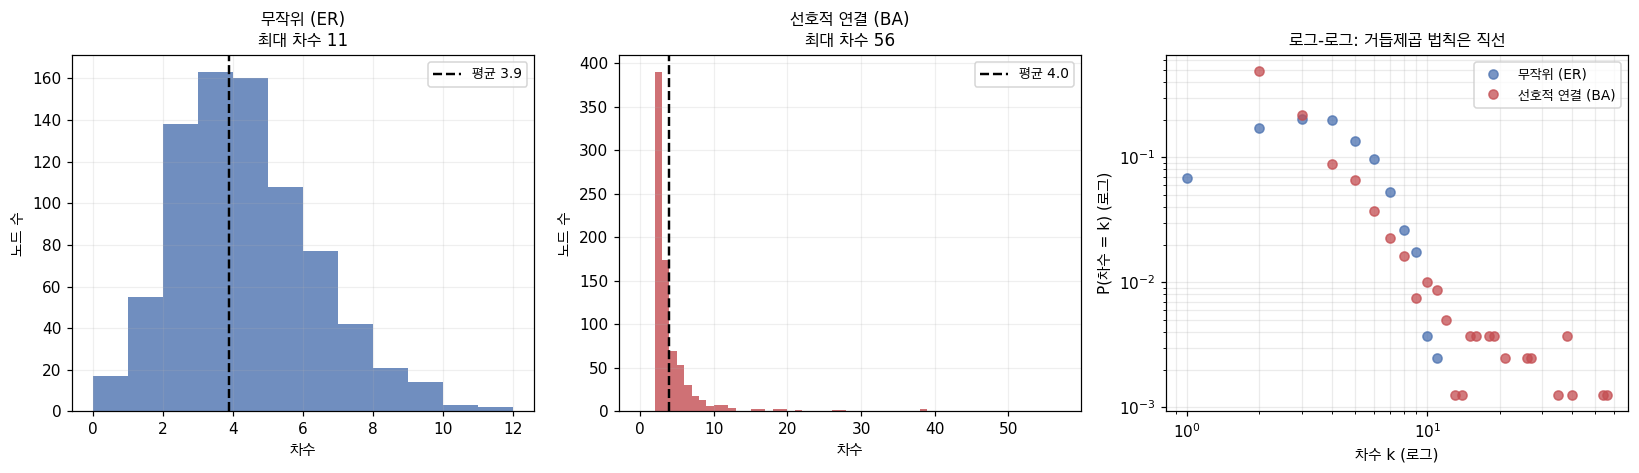

오른쪽 그림에서 빨간 점(BA)이 대략 직선을 이룹니다 = 거듭제곱 법칙.
파란 점(ER)은 평균 근처에서 뚝 떨어집니다 = 푸아송 분포.

💡 실무 의미: 소셜/인용 네트워크는 BA 쪽에 가깝습니다.
   그래서 '평균 차수'로 네트워크를 요약하면 허브의 존재를 완전히 놓칩니다.
   (6주차에서 배운 '평균이 분포를 대표하지 못하는' 상황의 그래프 버전입니다)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, (name, d), color in zip(axes[:2], degs.items(), ["#4c72b0", "#c44e52"]):
    ax.hist(d, bins=range(0, d.max()+2), color=color, alpha=0.8)
    ax.axvline(d.mean(), color="black", ls="--", lw=1.6, label=f"평균 {d.mean():.1f}")
    ax.set_xlabel("차수"); ax.set_ylabel("노드 수")
    ax.set_title(f"{name}\n최대 차수 {d.max()}", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

# 로그-로그로 보면 거듭제곱 법칙이 직선으로 나타납니다
ax = axes[2]
for (name, d), color in zip(degs.items(), ["#4c72b0", "#c44e52"]):
    cnt = Counter(d)
    ks = np.array(sorted(k for k in cnt if k > 0))
    ps = np.array([cnt[k] for k in ks], dtype=float) / len(d)
    ax.loglog(ks, ps, "o", ms=6, color=color, alpha=0.75, label=name)
ax.set_xlabel("차수 k (로그)"); ax.set_ylabel("P(차수 = k) (로그)")
ax.set_title("로그-로그: 거듭제곱 법칙은 직선", fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

print("오른쪽 그림에서 빨간 점(BA)이 대략 직선을 이룹니다 = 거듭제곱 법칙.")
print("파란 점(ER)은 평균 근처에서 뚝 떨어집니다 = 푸아송 분포.")
print("\n💡 실무 의미: 소셜/인용 네트워크는 BA 쪽에 가깝습니다.")
print("   그래서 '평균 차수'로 네트워크를 요약하면 허브의 존재를 완전히 놓칩니다.")
print("   (6주차에서 배운 '평균이 분포를 대표하지 못하는' 상황의 그래프 버전입니다)")

## 3️⃣ BFS와 DFS — 두 가지 탐색

그래프 탐색의 두 기본 알고리즘입니다. **둘 다 필요합니다.**

### 📐 너비 우선 탐색 (BFS) — 큐(FIFO)

이웃을 **전부** 먼저 방문하고, 그다음에 이웃의 이웃으로 갑니다. **물결이 퍼지듯** 나아가죠.

```
0에서 BFS:
  0 방문
  큐: [1, 2]      (0의 이웃)
  1 방문
  큐: [2, 3]      (1의 이웃 추가)
  2 방문
  3 방문 -> 종료
```

> 🔑 **BFS는 비가중 그래프에서 최단 경로를 찾습니다.**
> 어떤 노드가 처음 발견된 **BFS 레벨**이 곧 시작점으로부터의 거리입니다.
> 소셜 네트워크의 "몇 다리 건너"를 구할 때 쓰는 게 이겁니다.

### 📐 깊이 우선 탐색 (DFS) — 스택(LIFO) 또는 재귀

갈 수 있는 데까지 **깊이** 들어갔다가 막히면 되돌아옵니다. **미로를 한 손으로 벽 짚고 도는** 느낌이죠.

DFS가 유용한 곳:
- **연결 성분 찾기** (방문 안 한 노드에서 DFS를 반복)
- **사이클 탐지** (DFS 트리의 back edge)
- **위상 정렬** (DFS 종료 순서의 역순)

| 알고리즘 | 자료구조 | 찾는 것 | 쓰는 곳 |
| --- | --- | --- | --- |
| **BFS** | 큐 | **최단 경로** | 소셜 거리, 지식 그래프 탐색 |
| **DFS** | 스택 | 성분, 사이클 | 연결성, 위상 정렬 |

둘 다 모든 노드를 정확히 한 번씩 방문하므로 **O(V + E)** 입니다.

In [6]:
def bfs(graph, start):
    visited = {start}
    order, distances = [], {}
    queue = deque([(start, 0)])
    while queue:
        node, dist = queue.popleft()          # FIFO
        order.append(node)
        distances[node] = dist
        for nb in graph.neighbors(node):
            if nb not in visited:
                visited.add(nb)
                queue.append((nb, dist + 1))
    return order, distances

def dfs(graph, start):
    visited, order = set(), []
    stack = [start]
    while stack:
        node = stack.pop()                    # LIFO
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        for nb in reversed(graph.neighbors(node)):
            if nb not in visited:
                stack.append(nb)
    return order

# 예제 그래프
g = Graph(8)
for u, v in [(0,1), (0,2), (1,3), (2,3), (3,4), (4,5), (5,6), (2,6), (6,7)]:
    g.add_edge(u, v)

order_b, dist_b = bfs(g, 0)
order_d = dfs(g, 0)
print("그래프: 0-1, 0-2, 1-3, 2-3, 3-4, 4-5, 5-6, 2-6, 6-7\n")
print(f"  BFS 방문 순서: {order_b}")
print(f"  DFS 방문 순서: {order_d}")
print(f"\n  BFS가 구한 0으로부터의 거리: {dict(sorted(dist_b.items()))}")

print("\n[BFS 거리가 정말 최단 경로인가 — networkx와 대조]")
G_nx = nx.Graph([(u, v) for u in range(g.n) for v in g.neighbors(u) if u < v])
nx_dist = nx.single_source_shortest_path_length(G_nx, 0)
match = all(dist_b[k] == nx_dist[k] for k in dist_b)
print(f"  내 BFS 거리 == nx.shortest_path_length ?  {match} ✓")

print("\n[DFS로 연결 성분 찾기]")
def connected_components(graph):
    visited, comps = set(), []
    for node in range(graph.n):
        if node not in visited:
            comp = dfs(graph, node)
            visited.update(comp)
            comps.append(sorted(comp))
    return comps

g_split = Graph(9)
for u, v in [(0,1), (1,2), (0,2), (3,4), (4,5), (6,7)]:
    g_split.add_edge(u, v)
comps = connected_components(g_split)
print(f"  성분 {len(comps)}개: {comps}")
print(f"  (노드 8은 고립되어 혼자 하나의 성분입니다)")
print(f"  networkx 대조: {nx.number_connected_components(nx.Graph([(u,v) for u in range(9) for v in g_split.neighbors(u) if u<v] + [(8,8)]))}개")

그래프: 0-1, 0-2, 1-3, 2-3, 3-4, 4-5, 5-6, 2-6, 6-7

  BFS 방문 순서: [0, 1, 2, 3, 6, 4, 5, 7]
  DFS 방문 순서: [0, 1, 3, 2, 6, 5, 4, 7]

  BFS가 구한 0으로부터의 거리: {0: 0, 1: 1, 2: 1, 3: 2, 4: 3, 5: 3, 6: 2, 7: 3}

[BFS 거리가 정말 최단 경로인가 — networkx와 대조]
  내 BFS 거리 == nx.shortest_path_length ?  True ✓

[DFS로 연결 성분 찾기]
  성분 4개: [[0, 1, 2], [3, 4, 5], [6, 7], [8]]
  (노드 8은 고립되어 혼자 하나의 성분입니다)
  networkx 대조: 4개


### 🖼️ 그림 2 — BFS는 퍼지고, DFS는 파고듭니다

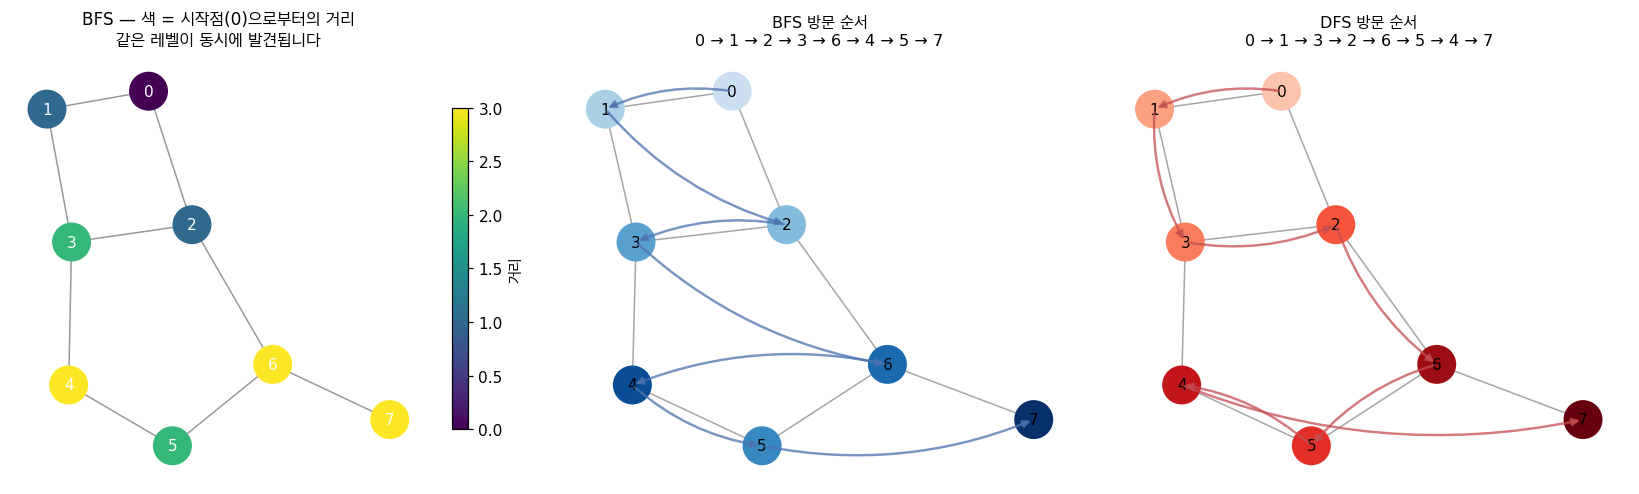

BFS는 0의 이웃(1,2)을 먼저 다 훑고 나서 다음 레벨로 갑니다.
DFS는 한 방향으로 끝까지 갔다가 되돌아옵니다 — 화살표가 멀리까지 뻗습니다.

💡 그래서 '최단 거리'가 필요하면 반드시 BFS를 써야 합니다.
   DFS가 먼저 도달한 경로는 최단이라는 보장이 전혀 없습니다.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

G_demo = nx.Graph()
for u in range(g.n):
    for v in g.neighbors(u):
        if u < v:
            G_demo.add_edge(u, v)
pos = nx.spring_layout(G_demo, seed=3)

# (1) BFS 레벨
levels = np.array([dist_b[i] for i in range(g.n)])
nx.draw_networkx_edges(G_demo, pos, ax=axes[0], alpha=0.4)
nc = nx.draw_networkx_nodes(G_demo, pos, ax=axes[0], node_color=levels,
                            cmap="viridis", node_size=600)
nx.draw_networkx_labels(G_demo, pos, ax=axes[0], font_size=10, font_color="white")
axes[0].set_title("BFS — 색 = 시작점(0)으로부터의 거리\n같은 레벨이 동시에 발견됩니다", fontsize=11)
axes[0].axis("off")
plt.colorbar(nc, ax=axes[0], shrink=0.75, label="거리")

# (2) 방문 순서 비교
for ax, order, name, color in [(axes[1], order_b, "BFS", "#4c72b0"),
                               (axes[2], order_d, "DFS", "#c44e52")]:
    step = {node: i for i, node in enumerate(order)}
    nx.draw_networkx_edges(G_demo, pos, ax=ax, alpha=0.35)
    nx.draw_networkx_nodes(G_demo, pos, ax=ax,
                           node_color=[step[i] for i in range(g.n)],
                           cmap="Reds" if name == "DFS" else "Blues",
                           node_size=600, vmin=-2)
    nx.draw_networkx_labels(G_demo, pos, ax=ax, font_size=10)
    # 방문 순서를 화살표로
    for a, b in zip(order[:-1], order[1:]):
        ax.annotate("", xy=pos[b], xytext=pos[a],
                    arrowprops=dict(arrowstyle="-|>", lw=1.6, color=color, alpha=0.75,
                                    connectionstyle="arc3,rad=0.15"))
    ax.set_title(f"{name} 방문 순서\n{' → '.join(map(str, order))}", fontsize=10.5)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("BFS는 0의 이웃(1,2)을 먼저 다 훑고 나서 다음 레벨로 갑니다.")
print("DFS는 한 방향으로 끝까지 갔다가 되돌아옵니다 — 화살표가 멀리까지 뻗습니다.")
print("\n💡 그래서 '최단 거리'가 필요하면 반드시 BFS를 써야 합니다.")
print("   DFS가 먼저 도달한 경로는 최단이라는 보장이 전혀 없습니다.")

## 4️⃣ 🔑 그래프 라플라시안 — 스펙트럴 그래프 이론의 심장

$$L = D - A$$

정의는 이게 전부입니다. 그런데 이 단순한 행렬이 **그래프의 구조를 전부 담고 있습니다.**

```
삼각형:
D = [[2,0,0],    A = [[0,1,1],    L = [[ 2,-1,-1],
     [0,2,0],         [1,0,1],         [-1, 2,-1],
     [0,0,2]]         [1,1,0]]         [-1,-1, 2]]
```

### 🔑 라플라시안을 이해하는 가장 좋은 방법 — '차이 측정기'

`L`을 벡터 `x`(각 노드에 붙은 값)에 곱하면 무슨 일이 일어날까요?

$$(Lx)_i = d_i x_i - \sum_{j \sim i} x_j = \sum_{j \sim i}(x_i - x_j)$$

> **`i`번 노드의 값과 이웃들 값의 차이를 전부 더한 것**입니다.

즉 `L`은 **"이 값이 이웃들과 얼마나 다른가"** 를 재는 연산자예요.
모든 노드의 값이 같으면 `Lx = 0`이 됩니다. 이게 5절 첫 번째 성질의 정체입니다.

그리고 이차형식을 계산하면 더 예뻐집니다.

$$x^\top L x = \sum_{(i,j) \in E} (x_i - x_j)^2$$

**엣지로 연결된 노드끼리의 값 차이를 제곱해서 다 더한 것**입니다.
이 값이 작으려면 **연결된 노드끼리 비슷한 값**을 가져야 하죠.
6절의 스펙트럴 군집화가 정확히 이 성질을 이용합니다.

> 💡 이름이 '라플라시안'인 이유도 여기 있습니다.
> 연속 공간의 라플라시안 `∇²`도 "주변 평균과의 차이"를 재는 연산자거든요.
> 그래프 버전이라 이렇게 부릅니다.

In [8]:
tri_L = tri.laplacian()
print("삼각형의 라플라시안 L = D - A =\n", tri_L.astype(int))
print(f"\n각 행의 합: {tri_L.sum(axis=1)}   <- 항상 0입니다 (대각 = 차수, 나머지 = -1씩)")

print("\n[L이 '차이 측정기'라는 것을 직접 확인]")
g_line = Graph(4)
for u, v in [(0,1), (1,2), (2,3)]:
    g_line.add_edge(u, v)
L_line = g_line.laplacian()

for name, x in [("모든 노드가 같은 값 [5,5,5,5]", np.array([5., 5, 5, 5])),
                ("한 노드만 다름 [5,5,9,5]", np.array([5., 5, 9, 5])),
                ("완만한 변화 [1,2,3,4]", np.array([1., 2, 3, 4]))]:
    Lx = L_line @ x
    quad = x @ L_line @ x
    print(f"  {name}")
    print(f"    Lx = {Lx}     xᵀLx = {quad:.1f}")

print("\n  => 값이 전부 같으면 Lx = 0, xᵀLx = 0 입니다.")
print("     '이웃과 다른 정도'가 0이라는 뜻이죠.")

print("\n[xᵀLx = 엣지별 차이 제곱의 합인지 검증]")
rng = np.random.default_rng(7)
x = rng.normal(size=4)
edges = [(0,1), (1,2), (2,3)]
manual = sum((x[i] - x[j])**2 for i, j in edges)
print(f"  x = {np.round(x, 4)}")
print(f"  xᵀLx                     = {x @ L_line @ x:.10f}")
print(f"  Σ_(i,j)∈E (xᵢ - xⱼ)²     = {manual:.10f}")
print(f"  차이: {abs(x @ L_line @ x - manual):.2e} ✓")

삼각형의 라플라시안 L = D - A =
 [[ 2 -1 -1]
 [-1  2 -1]
 [-1 -1  2]]

각 행의 합: [0. 0. 0.]   <- 항상 0입니다 (대각 = 차수, 나머지 = -1씩)

[L이 '차이 측정기'라는 것을 직접 확인]
  모든 노드가 같은 값 [5,5,5,5]
    Lx = [0. 0. 0. 0.]     xᵀLx = 0.0
  한 노드만 다름 [5,5,9,5]
    Lx = [ 0. -4.  8. -4.]     xᵀLx = 32.0
  완만한 변화 [1,2,3,4]
    Lx = [-1.  0.  0.  1.]     xᵀLx = 3.0

  => 값이 전부 같으면 Lx = 0, xᵀLx = 0 입니다.
     '이웃과 다른 정도'가 0이라는 뜻이죠.

[xᵀLx = 엣지별 차이 제곱의 합인지 검증]
  x = [ 0.0012  0.2987 -0.2741 -0.8906]
  xᵀLx                     = 0.7967262993
  Σ_(i,j)∈E (xᵢ - xⱼ)²     = 0.7967262993
  차이: 2.22e-16 ✓


## 5️⃣ 라플라시안의 네 가지 성질

여기가 이 노트북에서 가장 중요한 절입니다.

### 1️⃣ `L`은 양반정부호입니다 — 모든 고유값 ≥ 0

4절에서 `xᵀLx = Σ(xᵢ−xⱼ)² ≥ 0` 임을 봤죠. 제곱의 합이니 음수일 수 없습니다.
**7주차에서 배운 양반정부호의 정의 그 자체**입니다.

### 2️⃣ 0인 고유값의 개수 = 연결 성분의 개수

연결된 그래프는 **정확히 하나**의 0 고유값을 갖습니다(고유벡터는 전부 1인 벡터).
3개로 쪼개진 그래프는 **0이 세 개**입니다.

**왜?** `Lx = 0`이려면 모든 엣지에 대해 `xᵢ = xⱼ` 여야 합니다.
즉 **각 연결 성분 안에서 값이 일정**해야 하죠.
성분이 `k`개면 그런 벡터를 `k`개 만들 수 있으니 영공간의 차원이 `k`입니다.

> 🔑 **3절의 BFS/DFS로 세는 것과 완전히 같은 답이 나옵니다.**
> 탐색 없이 고유값만 세도 된다는 뜻이에요.

### 3️⃣ 가장 작은 0이 아닌 고유값 = 피들러 값 (대수적 연결도)

이 값이 **크면 그래프가 튼튼하게 연결**되어 있고,
**작으면 어딘가에 병목(약한 고리)** 이 있다는 뜻입니다.

### 4️⃣ 피들러 값의 고유벡터 = 최적 분할선

**피들러 벡터**의 값이 양수인 노드와 음수인 노드로 나누면
**그래프를 가장 자연스럽게 두 덩어리로 자르는 선**이 나옵니다.
이게 **스펙트럴 군집화**이고 6절의 주제입니다.

In [9]:
def laplacian_spectrum(graph):
    return np.linalg.eigvalsh(graph.laplacian())

print("[성질 1&2] 연결 성분 개수 = 0인 고유값 개수\n")
print(f"{'그래프':<32}{'BFS/DFS로 센 성분':>20}{'0인 고유값 개수':>18}{'일치':>8}")
print("-" * 80)

cases = []
# (a) 연결된 삼각형
cases.append(("연결된 삼각형", tri))
# (b) 두 덩어리
g2 = Graph(6)
for u, v in [(0,1), (1,2), (0,2), (3,4), (4,5), (3,5)]:
    g2.add_edge(u, v)
cases.append(("삼각형 2개 (분리)", g2))
# (c) 세 덩어리 + 고립 노드
g3 = Graph(9)
for u, v in [(0,1), (1,2), (3,4), (5,6), (6,7)]:
    g3.add_edge(u, v)
cases.append(("성분 3개 + 고립 노드 1개", g3))
# (d) 두 삼각형을 다리 하나로 연결
g4 = Graph(6)
for u, v in [(0,1), (1,2), (0,2), (3,4), (4,5), (3,5), (2,3)]:
    g4.add_edge(u, v)
cases.append(("삼각형 2개 + 다리 1개", g4))

for name, gg in cases:
    n_comp = len(connected_components(gg))
    eig = laplacian_spectrum(gg)
    n_zero = int(np.sum(np.abs(eig) < 1e-9))
    print(f"{name:<32}{n_comp:>20}{n_zero:>18}{'✓' if n_comp == n_zero else '✗':>8}")

print("\n=> 탐색으로 센 것과 고유값으로 센 것이 완전히 일치합니다.")
print("   '구조'와 '스펙트럼'이 같은 정보를 담고 있다는 첫 번째 증거입니다.")

print("\n[성질 3] 피들러 값 = 연결이 얼마나 튼튼한가")
print(f"{'그래프':<34}{'피들러 값':>12}{'해석':>26}")
print("-" * 74)
bridge_cases = [
    ("완전 그래프 K6 (모두 연결)", nx.complete_graph(6)),
    ("사이클 C6 (고리)", nx.cycle_graph(6)),
    ("경로 P6 (일자)", nx.path_graph(6)),
    ("아령형 (삼각형 2개 + 다리)", nx.barbell_graph(3, 0)),
]
for name, G_ in bridge_cases:
    L_ = nx.laplacian_matrix(G_).toarray().astype(float)
    eig = np.linalg.eigvalsh(L_)
    fied = eig[1]
    note = "매우 튼튼" if fied > 3 else ("보통" if fied > 0.7 else "병목 있음")
    print(f"{name:<34}{fied:>12.4f}{note:>26}")

print("\n=> 모두가 서로 연결된 K6는 피들러 값이 큽니다 (자르기 어려움).")
print("   일자로 늘어선 경로나 다리로 이어진 아령은 값이 작습니다 (자르기 쉬움).")
print("   즉 피들러 값은 '이 그래프를 두 동강 내기가 얼마나 어려운가'입니다.")

[성질 1&2] 연결 성분 개수 = 0인 고유값 개수

그래프                                    BFS/DFS로 센 성분         0인 고유값 개수      일치
--------------------------------------------------------------------------------
연결된 삼각형                                            1                 1       ✓
삼각형 2개 (분리)                                        2                 2       ✓
성분 3개 + 고립 노드 1개                                   4                 4       ✓
삼각형 2개 + 다리 1개                                     1                 1       ✓

=> 탐색으로 센 것과 고유값으로 센 것이 완전히 일치합니다.
   '구조'와 '스펙트럼'이 같은 정보를 담고 있다는 첫 번째 증거입니다.

[성질 3] 피들러 값 = 연결이 얼마나 튼튼한가
그래프                                      피들러 값                        해석
--------------------------------------------------------------------------
완전 그래프 K6 (모두 연결)                       6.0000                     매우 튼튼
사이클 C6 (고리)                             1.0000                        보통
경로 P6 (일자)                              0.2679                     병목 있음
아령형 (삼각형 2개 + 다리) 

### 🖼️ 그림 3 — 고유값이 구조를 말해 줍니다

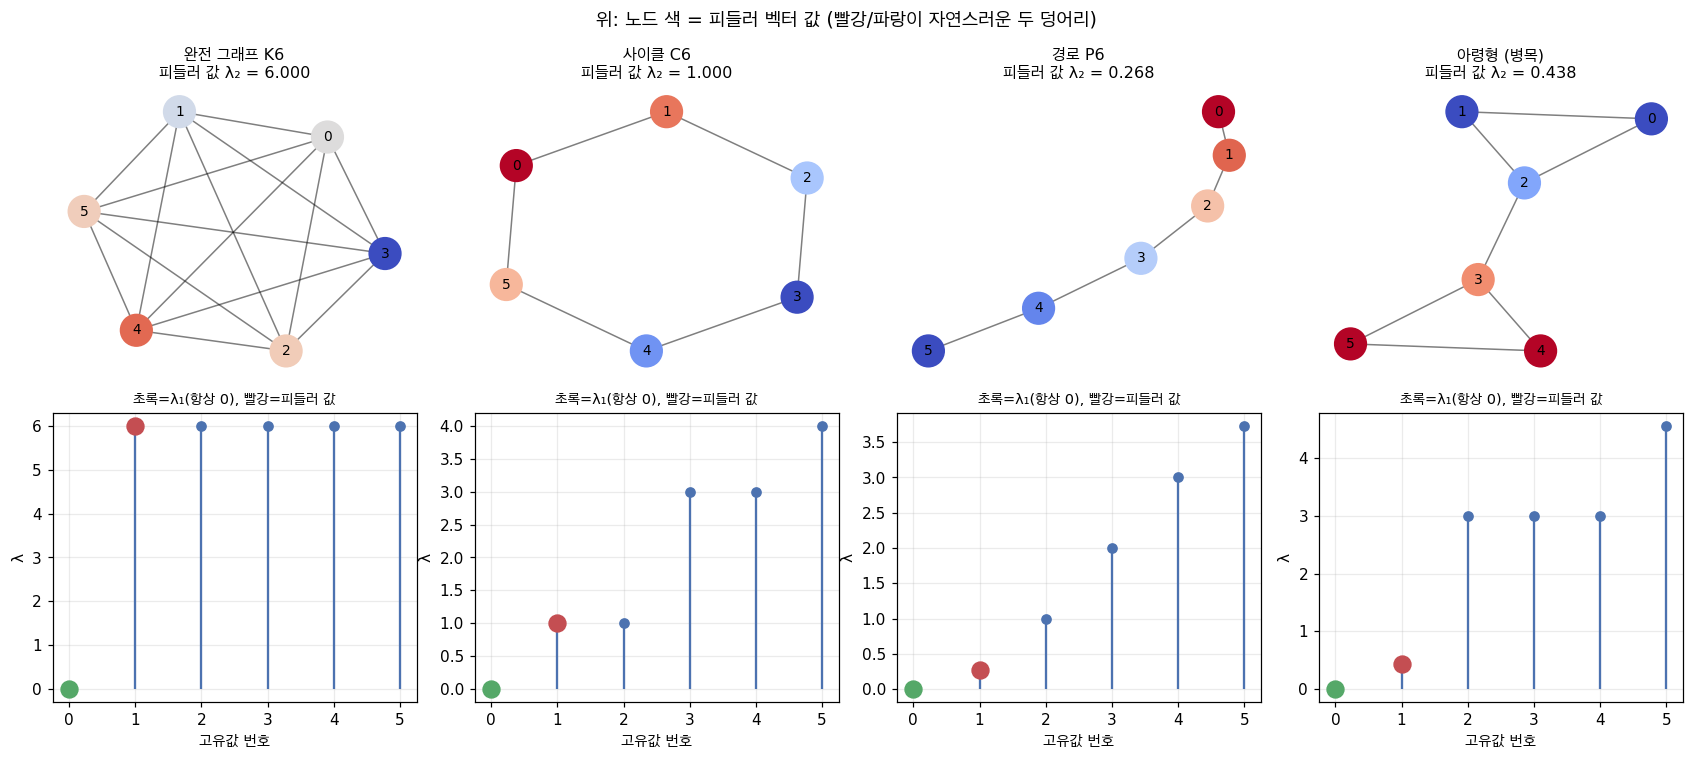

맨 오른쪽 아령형을 보세요. 피들러 벡터가 두 삼각형을 빨강/파랑으로 정확히 갈라놓았습니다.
그리고 피들러 값이 가장 작습니다 — '여기 병목이 있다'는 신호예요.
반대로 완전 그래프 K6는 색이 애매합니다. 자를 자연스러운 지점이 없으니까요.


In [10]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7))

show_graphs = [
    ("완전 그래프 K6", nx.complete_graph(6)),
    ("사이클 C6", nx.cycle_graph(6)),
    ("경로 P6", nx.path_graph(6)),
    ("아령형 (병목)", nx.barbell_graph(3, 0)),
]

for col, (name, G_) in enumerate(show_graphs):
    L_ = nx.laplacian_matrix(G_).toarray().astype(float)
    eig, vec = np.linalg.eigh(L_)
    pos_ = nx.spring_layout(G_, seed=5)

    ax = axes[0][col]
    fiedler = vec[:, 1]
    nx.draw_networkx_edges(G_, pos_, ax=ax, alpha=0.5)
    nx.draw_networkx_nodes(G_, pos_, ax=ax, node_color=fiedler, cmap="coolwarm",
                           node_size=430, vmin=-max(abs(fiedler)), vmax=max(abs(fiedler)))
    nx.draw_networkx_labels(G_, pos_, ax=ax, font_size=9)
    ax.set_title(f"{name}\n피들러 값 λ₂ = {eig[1]:.3f}", fontsize=10.5)
    ax.axis("off")

    ax = axes[1][col]
    ax.stem(range(len(eig)), eig, basefmt=" ", linefmt="#4c72b0", markerfmt="o")
    ax.plot([0], [eig[0]], "o", ms=11, color="#55a868", zorder=5)
    ax.plot([1], [eig[1]], "o", ms=11, color="#c44e52", zorder=5)
    ax.set_xlabel("고유값 번호"); ax.set_ylabel("λ")
    ax.set_title("초록=λ₁(항상 0), 빨강=피들러 값", fontsize=9.5)
    ax.grid(alpha=0.25)

plt.suptitle("위: 노드 색 = 피들러 벡터 값 (빨강/파랑이 자연스러운 두 덩어리)", fontsize=12.5)
plt.tight_layout()
plt.show()

print("맨 오른쪽 아령형을 보세요. 피들러 벡터가 두 삼각형을 빨강/파랑으로 정확히 갈라놓았습니다.")
print("그리고 피들러 값이 가장 작습니다 — '여기 병목이 있다'는 신호예요.")
print("반대로 완전 그래프 K6는 색이 애매합니다. 자를 자연스러운 지점이 없으니까요.")

## 6️⃣ 🔨 스펙트럴 군집화와 피들러 벡터

라플라시안의 고유벡터로 그래프를 나누는 방법입니다.

```
1. 라플라시안 L을 계산한다
2. 가장 작은 k개의 고유벡터를 구한다 (첫 번째는 버립니다 — 전부 1인 자명한 벡터)
3. 그 고유벡터들을 각 노드의 '새 좌표'로 삼는다
4. 그 좌표에 k-means를 돌린다
```

`k = 2` 라면 더 간단합니다. **피들러 벡터의 부호만 보면 됩니다.**

### 🔑 왜 이게 작동하는가

4절에서 본 식을 다시 봅시다.

$$x^\top L x = \sum_{(i,j)\in E}(x_i - x_j)^2$$

이 값을 **최소화**하는 `x`를 찾으면(단, 자명한 해 `x = 상수`는 제외),
**연결된 노드끼리는 비슷한 값**을 갖게 됩니다.
그리고 그 최소해가 정확히 **피들러 벡터**입니다.

> 즉 스펙트럴 군집화는 **"엣지를 최소한으로 자르는 분할"** 을 고유값 문제로 바꿔 푼 것입니다.
> 조합 최적화 문제를 **고유분해 한 번**으로 해결하는 거죠. 반복 최적화가 필요 없습니다.

### ⚠️ 그런데 만능은 아닙니다

두 덩어리 사이를 잇는 엣지가 많아지면 성능이 떨어집니다.
아래에서 **다리 개수를 늘려가며 언제 무너지는지** 직접 확인해 보겠습니다.

In [11]:
def spectral_bipartition(A):
    D = np.diag(A.sum(axis=1))
    L = D - A
    eig, vec = np.linalg.eigh(L)
    fiedler = vec[:, 1]
    return (fiedler >= 0).astype(int), eig[1], fiedler

def two_cliques(size, n_bridges, seed=0):
    # 완전 그래프 두 개를 n_bridges개의 엣지로 연결
    rng = np.random.default_rng(seed)
    n = 2 * size
    A = np.zeros((n, n))
    for grp in range(2):
        base = grp * size
        for i in range(size):
            for j in range(i+1, size):
                A[base+i, base+j] = A[base+j, base+i] = 1
    pairs = rng.permutation([(i, size+j) for i in range(size) for j in range(size)])
    for i, j in pairs[:n_bridges]:
        A[i, j] = A[j, i] = 1
    return A

SIZE = 10
truth = np.r_[np.zeros(SIZE, int), np.ones(SIZE, int)]

MAX_BRIDGES = SIZE * SIZE          # 두 클리크를 잇는 '가능한 모든' 엣지 수
print("연습 2 — 두 클리크 사이의 다리를 늘려 가면?\n")
print(f"각 클리크: 노드 {SIZE}개, 내부 엣지 {SIZE*(SIZE-1)//2}개")
print(f"다리는 최대 {MAX_BRIDGES}개까지 놓을 수 있습니다 (그러면 완전 이분 연결)\n")
print(f"{'다리 수':>9}{'가능한 다리 중':>14}{'피들러 값':>12}{'정확도(시드8개 평균)':>22}{'판정':>10}")
print("-" * 70)
for nb in [1, 5, 20, 45, 60, 80, 90, 100]:
    accs = []
    for sd in range(8):
        labels, _, _ = spectral_bipartition(two_cliques(SIZE, nb, seed=sd))
        accs.append(max((labels == truth).mean(), (labels != truth).mean()))
    _, fied, _ = spectral_bipartition(two_cliques(SIZE, nb, seed=2))
    m = float(np.mean(accs))
    verdict = "✅ 완벽" if m > 0.99 else ("⚠️ 흔들림" if m > 0.7 else "❌ 실패")
    print(f"{nb:>9}{nb/MAX_BRIDGES:>13.0%}{fied:>12.3f}{m:>21.1%}{verdict:>10}")

print("\n=> 생각보다 훨씬 오래 버팁니다. 다리가 45개(내부 엣지 수와 같은 수준)여도 거의 완벽합니다.")
print("   무너지기 시작하는 건 다리가 '가능한 전부'에 가까워질 때(80~90개)입니다.")
print("   그쯤 되면 두 클리크가 사실상 하나의 큰 덩어리라 '자를 곳'이 정말 없는 거죠.")
print("\n   💡 피들러 값이 함께 커지는 것을 보세요. 이 값이 크다는 건")
print("      '이 그래프에는 자연스러운 절단면이 없다'는 경고이기도 합니다.")
print("      즉 피들러 값은 군집화 결과를 얼마나 믿을지 알려주는 지표입니다.")

연습 2 — 두 클리크 사이의 다리를 늘려 가면?

각 클리크: 노드 10개, 내부 엣지 45개
다리는 최대 100개까지 놓을 수 있습니다 (그러면 완전 이분 연결)

     다리 수      가능한 다리 중       피들러 값          정확도(시드8개 평균)        판정
----------------------------------------------------------------------
        1           1%       0.169               100.0%      ✅ 완벽
        5           5%       0.837               100.0%      ✅ 완벽
       20          20%       3.653               100.0%      ✅ 완벽
       45          45%       7.849                99.4%      ✅ 완벽
       60          60%      10.183                99.4%      ✅ 완벽
       80          80%      13.472                91.2%    ⚠️ 흔들림
       90          90%      15.830                71.9%    ⚠️ 흔들림
      100         100%      20.000                55.0%      ❌ 실패

=> 생각보다 훨씬 오래 버팁니다. 다리가 45개(내부 엣지 수와 같은 수준)여도 거의 완벽합니다.
   무너지기 시작하는 건 다리가 '가능한 전부'에 가까워질 때(80~90개)입니다.
   그쯤 되면 두 클리크가 사실상 하나의 큰 덩어리라 '자를 곳'이 정말 없는 거죠.

   💡 피들러 값이 함께 커지는 것을 보세요. 이 값이 크다는 건
      '이 그래프에는 자연스러운 절단면이 없다'는 경고이기도 합니다.
    

### 🖼️ 그림 4 — 다리가 늘어나면 경계가 흐려집니다

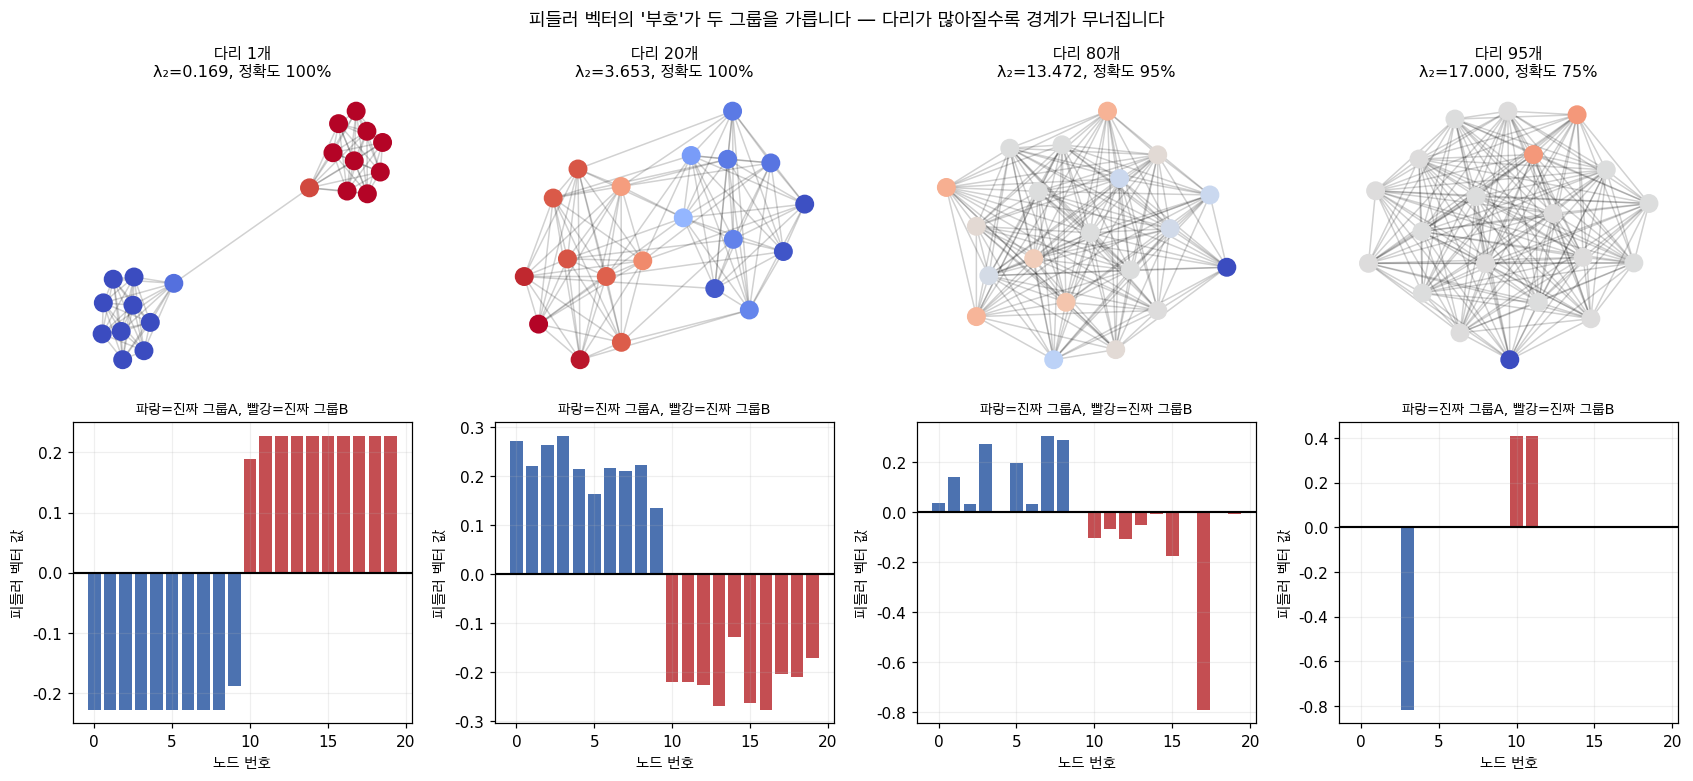

아래 막대그래프를 보세요.
  다리 1~20개: 파란 막대는 전부 한쪽, 빨간 막대는 전부 반대쪽 — 부호로 완벽히 갈립니다.
  다리 95개: 파랑과 빨강이 0선 양쪽에 섞이기 시작합니다 — 구분이 무너집니다.


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7.2))
for col, nb in enumerate([1, 20, 80, 95]):
    A_c = two_cliques(SIZE, nb, seed=2)
    labels, fied, fvec = spectral_bipartition(A_c)
    acc = max((labels == truth).mean(), (labels != truth).mean())
    G_c = nx.from_numpy_array(A_c)
    pos_c = nx.spring_layout(G_c, seed=1)

    ax = axes[0][col]
    nx.draw_networkx_edges(G_c, pos_c, ax=ax, alpha=0.18)
    nx.draw_networkx_nodes(G_c, pos_c, ax=ax, node_color=fvec, cmap="coolwarm",
                           node_size=130, vmin=-max(abs(fvec)), vmax=max(abs(fvec)))
    ax.set_title(f"다리 {nb}개\nλ₂={fied:.3f}, 정확도 {acc:.0%}", fontsize=10.5)
    ax.axis("off")

    ax = axes[1][col]
    colors = ["#4c72b0"] * SIZE + ["#c44e52"] * SIZE
    ax.bar(range(2*SIZE), np.sort(fvec) if False else fvec, color=colors)
    ax.axhline(0, color="black", lw=1.4)
    ax.set_xlabel("노드 번호"); ax.set_ylabel("피들러 벡터 값")
    ax.set_title("파랑=진짜 그룹A, 빨강=진짜 그룹B", fontsize=9.5)
    ax.grid(alpha=0.2)

plt.suptitle("피들러 벡터의 '부호'가 두 그룹을 가릅니다 — 다리가 많아질수록 경계가 무너집니다",
             fontsize=12.5)
plt.tight_layout()
plt.show()

print("아래 막대그래프를 보세요.")
print("  다리 1~20개: 파란 막대는 전부 한쪽, 빨간 막대는 전부 반대쪽 — 부호로 완벽히 갈립니다.")
print("  다리 95개: 파랑과 빨강이 0선 양쪽에 섞이기 시작합니다 — 구분이 무너집니다.")

## 7️⃣ 🔨 메시지 패싱 — GNN의 핵심 연산

이제 GNN의 심장부입니다. 각 노드가 **이웃에게서 메시지를 모아, 합치고, 자기 상태를 갱신**합니다.

$$h_v^{(k+1)} = \text{UPDATE}\Big(h_v^{(k)},\ \text{AGGREGATE}\big(\{h_u^{(k)} : u \in N(v)\}\big)\Big)$$

가장 단순한 형태는 **AGGREGATE = 평균**, **UPDATE = 선형변환 + 활성화**입니다.

$$h_v^{(k+1)} = \sigma\Big(W \cdot \text{mean}\{h_u^{(k)} : u \in N(v)\}\Big)$$

### 🔑 그런데 이건 사실 행렬 곱셈입니다

노드 특징을 행렬 `H`로 모으고, 정규화된 인접 행렬을 `Â`라 하면:

$$H^{(k+1)} = \sigma\big(\hat{A}\, H^{(k)}\, W\big)$$

**for 루프로 이웃을 순회하는 대신 행렬 곱 하나**로 끝납니다.
그래서 GPU에서 빠르게 돌아가는 거예요.

- `Â H` → **이웃 특징의 평균을 낸다** (그래프 구조가 쓰이는 지점)
- `(·) W` → **특징을 변환한다** (학습되는 지점)

### 🔑 K번 반복하면 K-hop을 봅니다

메시지 패싱 **1라운드**면 각 노드가 **직접 이웃**을 봅니다.
**2라운드**면 이웃의 이웃까지, **K라운드**면 **K-hop 이웃**의 정보가 도달합니다.

1절에서 본 `A^k` = "길이 k 경로의 개수"가 여기서 다시 나옵니다.
아래에서 정보가 실제로 퍼지는 걸 눈으로 확인해 보겠습니다.

In [13]:
def normalize_adjacency(A, add_self_loops=False, symmetric=False):
    A = A.copy().astype(float)
    if add_self_loops:
        A = A + np.eye(len(A))
    deg = A.sum(axis=1)
    if symmetric:                                     # D^(-1/2) A D^(-1/2)  (GCN 방식)
        d_inv_sqrt = np.where(deg > 0, 1/np.sqrt(np.maximum(deg, 1e-12)), 0)
        return A * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]
    deg = np.where(deg == 0, 1, deg)                  # D^(-1) A  (행 평균)
    return A / deg[:, None]

def message_passing(A_norm, H, W=None, activation=None):
    out = A_norm @ H
    if W is not None:
        out = out @ W
    if activation is not None:
        out = activation(out)
    return out

# 삼각형에서 손으로 확인 (원문 예시)
A_tri = tri.adjacency_matrix()
H0 = np.array([[1., 0.], [0., 1.], [1., 1.]])         # A=[1,0], B=[0,1], C=[1,1]
A_norm_tri = normalize_adjacency(A_tri)
H1 = message_passing(A_norm_tri, H0)

print("삼각형 (모든 노드가 서로 연결), 초기 특징:")
for i, name in enumerate("ABC"):
    print(f"  노드 {name}: {H0[i]}")
print("\n메시지 패싱 1회 (이웃 평균):")
for i, name in enumerate("ABC"):
    nbs = [n for n in "ABC" if n != name]
    print(f"  노드 {name}: {H1[i]}   = avg({', '.join(nbs)})")
print("\n  손 계산 확인: A의 새 특징 = avg(B, C) = avg([0,1],[1,1]) = [0.5, 1.0] ✓")

print("\n[🔑 정보가 몇 홉까지 퍼지는가]")
# 경로 그래프에서 노드 0에만 신호를 주고 퍼지는 걸 봅니다
n_line = 9
g_l = Graph(n_line)
for i in range(n_line - 1):
    g_l.add_edge(i, i+1)
A_l = g_l.adjacency_matrix()
A_l_norm = normalize_adjacency(A_l, add_self_loops=True)      # 자기 자신도 포함

H = np.zeros((n_line, 1))
H[0, 0] = 1.0                                                  # 0번 노드에만 신호
print(f"  경로 그래프 0-1-2-...-{n_line-1},  0번 노드에만 신호 1을 넣습니다\n")
print(f"{'라운드':>8}  " + "".join(f"{i:>8}" for i in range(n_line)))
print("-" * 80)
for k in range(5):
    reached = int(np.sum(H[:, 0] > 1e-12))
    print(f"{k:>8}  " + "".join(f"{v:>8.3f}" for v in H[:, 0]) + f"   도달 {reached}개")
    H = message_passing(A_l_norm, H)

print("\n=> 라운드마다 신호가 정확히 한 칸씩 더 퍼집니다.")
print("   K라운드 = K-hop 이웃까지 정보 도달. 이게 GNN 층 수를 정하는 기준입니다.")

삼각형 (모든 노드가 서로 연결), 초기 특징:
  노드 A: [1. 0.]
  노드 B: [0. 1.]
  노드 C: [1. 1.]

메시지 패싱 1회 (이웃 평균):
  노드 A: [0.5 1. ]   = avg(B, C)
  노드 B: [1.  0.5]   = avg(A, C)
  노드 C: [0.5 0.5]   = avg(A, B)

  손 계산 확인: A의 새 특징 = avg(B, C) = avg([0,1],[1,1]) = [0.5, 1.0] ✓

[🔑 정보가 몇 홉까지 퍼지는가]
  경로 그래프 0-1-2-...-8,  0번 노드에만 신호 1을 넣습니다

     라운드         0       1       2       3       4       5       6       7       8
--------------------------------------------------------------------------------
       0     1.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   0.000   도달 1개
       1     0.500   0.333   0.000   0.000   0.000   0.000   0.000   0.000   0.000   도달 2개
       2     0.417   0.278   0.111   0.000   0.000   0.000   0.000   0.000   0.000   도달 3개
       3     0.347   0.269   0.130   0.037   0.000   0.000   0.000   0.000   0.000   도달 4개
       4     0.308   0.248   0.145   0.056   0.012   0.000   0.000   0.000   0.000   도달 5개

=> 라운드마다 신호가 정확히 한 칸씩 더 퍼집니다.
   K라운드 = K-hop 이웃까지 정보 도달. 이게

### 🖼️ 그림 5 — 메시지가 퍼져 나가는 모습

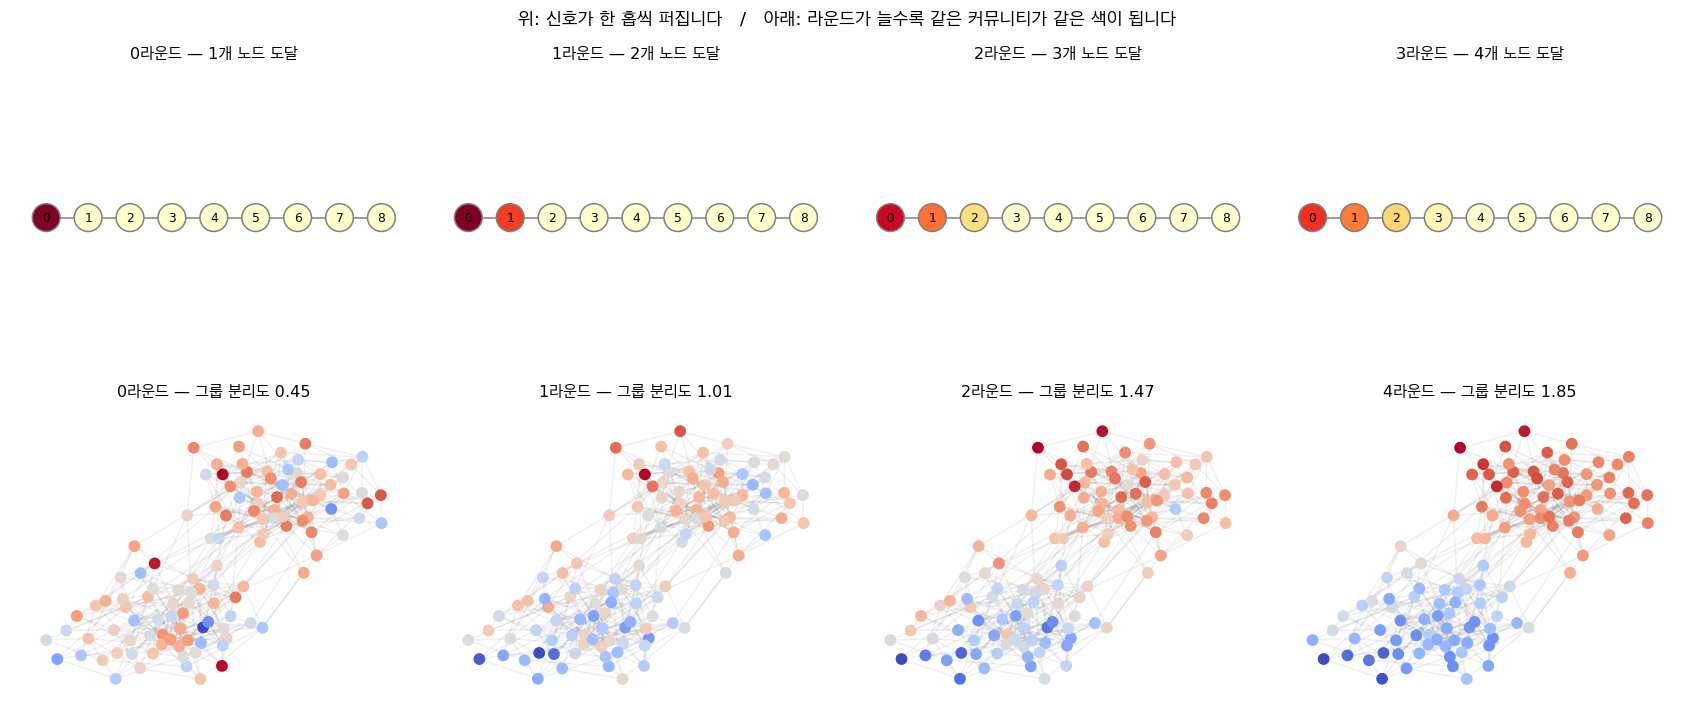

아래 줄에서 처음에는 색이 뒤죽박죽인데, 라운드가 늘수록 왼쪽 덩어리와
오른쪽 덩어리의 색이 갈라집니다. '분리도' 숫자가 그걸 정량화한 것입니다.

⚠️ 다만 라운드를 무한정 늘리면 안 됩니다. 8절에서 그 이유를 봅니다.


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 6.6))

# 위: 경로 그래프에서의 전파
G_l = nx.path_graph(n_line)
pos_l = {i: (i, 0) for i in range(n_line)}
H = np.zeros((n_line, 1)); H[0, 0] = 1.0
for k in range(4):
    ax = axes[0][k]
    nx.draw_networkx_edges(G_l, pos_l, ax=ax, alpha=0.5)
    nx.draw_networkx_nodes(G_l, pos_l, ax=ax, node_color=H[:, 0], cmap="YlOrRd",
                           node_size=330, vmin=0, vmax=0.5, edgecolors="gray")
    nx.draw_networkx_labels(G_l, pos_l, ax=ax, font_size=8)
    ax.set_title(f"{k}라운드 — {int(np.sum(H[:,0] > 1e-12))}개 노드 도달", fontsize=10.5)
    ax.axis("off")
    H = message_passing(A_l_norm, H)

# 아래: 2-커뮤니티 그래프에서 특징이 매끄러워지는 모습
A_comm = A_struct
A_comm_norm = normalize_adjacency(A_comm, add_self_loops=True)
G_comm = nx.from_numpy_array(A_comm)
pos_comm = nx.spring_layout(G_comm, seed=4)
Hc = X.copy()
for k, ax in zip([0, 1, 2, 4], axes[1]):
    Htmp = X.copy()
    for _ in range(k):
        Htmp = message_passing(A_comm_norm, Htmp)
    nx.draw_networkx_edges(G_comm, pos_comm, ax=ax, alpha=0.06)
    nx.draw_networkx_nodes(G_comm, pos_comm, ax=ax, node_color=Htmp[:, 0],
                           cmap="coolwarm", node_size=45)
    # 분리도(두 그룹 평균 차이 / 표준편차)
    sep = abs(Htmp[labels_true==0,0].mean() - Htmp[labels_true==1,0].mean()) / (Htmp[:,0].std()+1e-12)
    ax.set_title(f"{k}라운드 — 그룹 분리도 {sep:.2f}", fontsize=10.5)
    ax.axis("off")

plt.suptitle("위: 신호가 한 홉씩 퍼집니다   /   아래: 라운드가 늘수록 같은 커뮤니티가 같은 색이 됩니다",
             fontsize=12)
plt.tight_layout()
plt.show()

print("아래 줄에서 처음에는 색이 뒤죽박죽인데, 라운드가 늘수록 왼쪽 덩어리와")
print("오른쪽 덩어리의 색이 갈라집니다. '분리도' 숫자가 그걸 정량화한 것입니다.")
print("\n⚠️ 다만 라운드를 무한정 늘리면 안 됩니다. 8절에서 그 이유를 봅니다.")

## 8️⃣ 🏭 GCN — 왜 하필 그 정규화인가

Kipf & Welling(2017)의 **GCN** 층은 이렇게 생겼습니다.

$$H^{(l+1)} = \sigma\Big(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} H^{(l)} W^{(l)}\Big)$$

여기서 `Â = A + I`(자기 루프 추가)이고 `D̂`는 `Â`의 차수 행렬입니다.

### 🔑 두 가지 설계 결정을 뜯어봅시다

**① 왜 자기 루프(`+I`)를 더하나**

자기 루프가 없으면 `Â H`가 **이웃 정보만** 모읍니다. **자기 자신의 특징은 사라집니다.**
`+I`는 "내 정보도 함께 고려하라"는 뜻이에요.

**② 왜 대칭 정규화 `D^(-1/2) A D^(-1/2)` 인가**

행 정규화 `D⁻¹A`(단순 평균)와 뭐가 다를까요?

- **`D⁻¹A`**: 각 노드가 이웃 평균을 냅니다. 그런데 **차수가 큰 이웃이 보내는 메시지도 똑같이 취급**합니다.
- **`D^(-1/2)AD^(-1/2)`**: 보내는 쪽과 받는 쪽 **양쪽의 차수로 나눕니다.**
  허브 노드가 모든 이웃을 지배하는 걸 막아 줍니다.

그리고 이 행렬은 **대칭 라플라시안과 직접 연결**됩니다.

$$L_{\text{sym}} = I - D^{-1/2}AD^{-1/2}$$

> **즉 GCN의 전파 행렬은 `I − L_sym`입니다.**
> 라플라시안을 이해하면 GCN이 왜 작동하는지 이해한 겁니다.

### ⚠️ 과도한 평활화 (over-smoothing)

메시지 패싱을 너무 많이 반복하면 **모든 노드의 특징이 똑같아집니다.**
반복 곱셈이 결국 **라플라시안의 최소 고유벡터(= 상수 벡터)로 수렴**하기 때문이에요.

그래서 실전 GCN은 보통 **2~3층**만 씁니다. 아래에서 직접 확인해 보겠습니다.

In [15]:
A_c = A_struct
print("정규화 방식 비교 — 허브 노드가 있는 그래프에서\n")

# 허브가 있는 작은 그래프
g_hub = Graph(7)
for v in [1, 2, 3, 4]:
    g_hub.add_edge(0, v)          # 0번이 허브
g_hub.add_edge(5, 6)
g_hub.add_edge(4, 5)
A_h = g_hub.adjacency_matrix()

print(f"차수: {[g_hub.degree(i) for i in range(7)]}   (0번이 허브)")
row_n = normalize_adjacency(A_h, add_self_loops=True, symmetric=False)
sym_n = normalize_adjacency(A_h, add_self_loops=True, symmetric=True)
print(f"\n노드 4가 받는 메시지의 가중치 (이웃: 0번 허브[차수 {g_hub.degree(0)}], 5번[차수 {g_hub.degree(5)}])")
print(f"  행 정규화 D⁻¹Â   : 0번에서 {row_n[4,0]:.4f}, 5번에서 {row_n[4,5]:.4f}, 자기 {row_n[4,4]:.4f}")
print(f"  대칭 정규화       : 0번에서 {sym_n[4,0]:.4f}, 5번에서 {sym_n[4,5]:.4f}, 자기 {sym_n[4,4]:.4f}")
print(f"  => 행 정규화는 세 이웃을 똑같이 1/3씩 취급합니다.")
print(f"     대칭 정규화는 차수가 큰 허브(0번)의 메시지만 {sym_n[4,0]:.4f}로 낮춥니다.")
print("     허브가 그래프 전체를 지배하는 걸 막는 장치입니다.")

print("\n[🔑 GCN 전파 행렬 = I - L_sym 확인]")
A_hat = A_h + np.eye(7)
D_hat = np.diag(A_hat.sum(1))
D_inv_sqrt = np.diag(1/np.sqrt(np.diag(D_hat)))
prop = D_inv_sqrt @ A_hat @ D_inv_sqrt
L_sym = np.eye(7) - prop
print(f"  전파행렬 + L_sym = I 인가?  최대 오차 {np.abs(prop + L_sym - np.eye(7)).max():.2e} ✓")
print(f"  L_sym의 고유값 범위: [{np.linalg.eigvalsh(L_sym).min():.4f}, "
      f"{np.linalg.eigvalsh(L_sym).max():.4f}]  (항상 [0, 2] 안에 있습니다)")

정규화 방식 비교 — 허브 노드가 있는 그래프에서

차수: [4, 1, 1, 1, 2, 2, 1]   (0번이 허브)

노드 4가 받는 메시지의 가중치 (이웃: 0번 허브[차수 4], 5번[차수 2])
  행 정규화 D⁻¹Â   : 0번에서 0.3333, 5번에서 0.3333, 자기 0.3333
  대칭 정규화       : 0번에서 0.2582, 5번에서 0.3333, 자기 0.3333
  => 행 정규화는 세 이웃을 똑같이 1/3씩 취급합니다.
     대칭 정규화는 차수가 큰 허브(0번)의 메시지만 0.2582로 낮춥니다.
     허브가 그래프 전체를 지배하는 걸 막는 장치입니다.

[🔑 GCN 전파 행렬 = I - L_sym 확인]
  전파행렬 + L_sym = I 인가?  최대 오차 0.00e+00 ✓
  L_sym의 고유값 범위: [-0.0000, 1.3247]  (항상 [0, 2] 안에 있습니다)


In [16]:
# ⚠️ 과도한 평활화 — 층을 너무 쌓으면 모든 노드가 같아집니다
A_norm_sym = normalize_adjacency(A_struct, add_self_loops=True, symmetric=True)
H = X.copy()

print("층을 쌓을수록 노드 특징이 어떻게 되나 (2커뮤니티 그래프, 120노드)\n")
print(f"{'층 수':>8}{'특징 표준편차':>16}{'그룹 분리도':>16}{'군집 정확도':>16}")
print("-" * 58)
for k in range(0, 33):
    if k in (0, 1, 2, 3, 5, 8, 16, 32):
        sd = H[:, 0].std()
        sep = abs(H[labels_true==0,0].mean() - H[labels_true==1,0].mean()) / (sd + 1e-15)
        acc = max((H[:,0] > np.median(H[:,0])).astype(int).__eq__(labels_true).mean(),
                  1 - (H[:,0] > np.median(H[:,0])).astype(int).__eq__(labels_true).mean())
        print(f"{k:>8}{sd:>16.3e}{sep:>16.3f}{acc:>15.1%}")
    H = A_norm_sym @ H

print("\n=> 분리도가 올라가다가 어느 지점에서 정점을 찍고 다시 내려갑니다.")
print("   특징 표준편차가 0으로 수렴하는 것도 보세요 — 모든 노드가 같은 값이 되는 겁니다.")
print("\n   💡 이게 '과도한 평활화(over-smoothing)'입니다.")
print("      반복 곱셈이 결국 라플라시안의 최소 고유벡터(상수 벡터) 쪽으로 수렴하기 때문입니다.")
print("\n   ⚠️ 여기서는 최적 층수가 2~3층보다 큽니다. 실전 GCN 권장값(2~3층)과 다른데,")
print("      이유가 있습니다:")
print("        · 이 데모는 학습 가능한 W 없이 순수 평활화만 반복합니다.")
print("          실제 GCN은 층마다 W가 특징을 다시 펼쳐 주므로 평활화가 더 빨리 해롭습니다.")
print("        · 여기 신호는 노이즈에 거의 묻혀 있어서, 평균을 오래 낼수록 이득이 큽니다.")
print("      공통점은 분명합니다 — '깊을수록 좋다'가 절대 아니고, 최적점을 넘으면 나빠집니다.")

층을 쌓을수록 노드 특징이 어떻게 되나 (2커뮤니티 그래프, 120노드)

     층 수         특징 표준편차          그룹 분리도          군집 정확도
----------------------------------------------------------
       0       1.301e+00           0.455          63.3%
       1       4.678e-01           1.045          71.7%
       2       2.956e-01           1.498          90.0%
       3       2.363e-01           1.729          95.0%
       5       1.859e-01           1.869         100.0%
       8       1.444e-01           1.879         100.0%
      16       8.045e-02           1.743          98.3%
      32       4.043e-02           0.979          68.3%

=> 분리도가 올라가다가 어느 지점에서 정점을 찍고 다시 내려갑니다.
   특징 표준편차가 0으로 수렴하는 것도 보세요 — 모든 노드가 같은 값이 되는 겁니다.

   💡 이게 '과도한 평활화(over-smoothing)'입니다.
      반복 곱셈이 결국 라플라시안의 최소 고유벡터(상수 벡터) 쪽으로 수렴하기 때문입니다.

   ⚠️ 여기서는 최적 층수가 2~3층보다 큽니다. 실전 GCN 권장값(2~3층)과 다른데,
      이유가 있습니다:
        · 이 데모는 학습 가능한 W 없이 순수 평활화만 반복합니다.
          실제 GCN은 층마다 W가 특징을 다시 펼쳐 주므로 평활화가 더 빨리 해롭습니다.
        · 여기 신호는 노이즈에 거의 묻혀 있어서, 평균을 오래 낼

### 🖼️ 그림 6 — 과도한 평활화

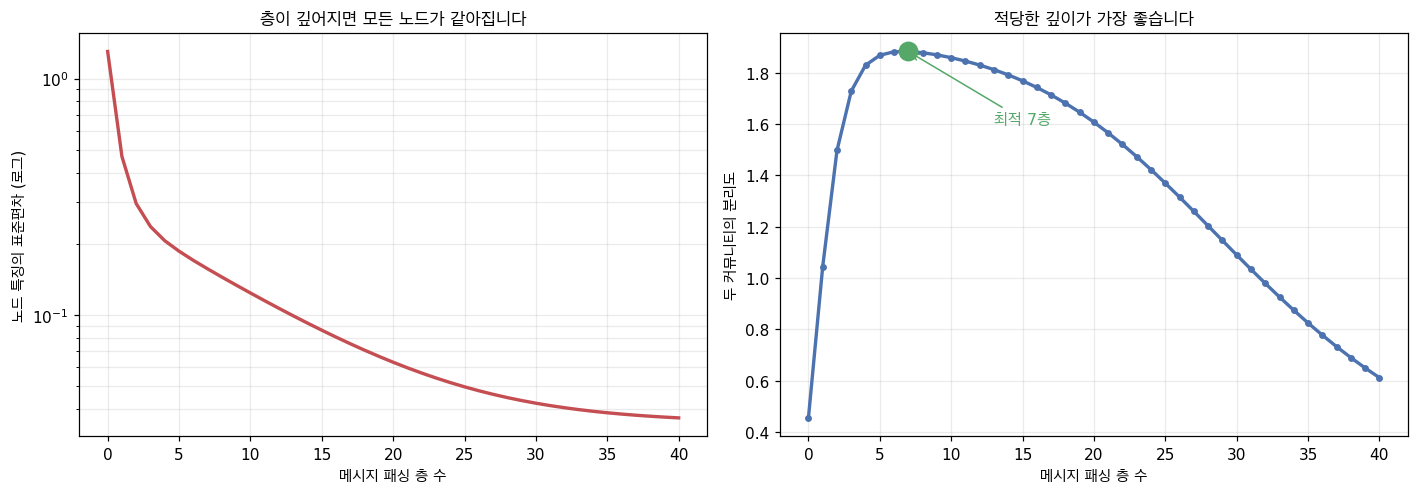

분리도가 7층에서 최대이고, 그 뒤로는 떨어집니다.
왼쪽에서 표준편차가 지수적으로 0에 수렴하는 게 그 원인입니다.
정보를 더 멀리 보내려는 욕심과 특징을 구분되게 유지하려는 요구가 충돌하는 지점입니다.


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

H = X.copy()
ks, sds, seps = [], [], []
for k in range(41):
    ks.append(k)
    sds.append(H[:, 0].std())
    seps.append(abs(H[labels_true==0,0].mean() - H[labels_true==1,0].mean()) / (H[:,0].std()+1e-15))
    H = A_norm_sym @ H

ax1.semilogy(ks, sds, lw=2.2, color="#c44e52")
ax1.set_xlabel("메시지 패싱 층 수"); ax1.set_ylabel("노드 특징의 표준편차 (로그)")
ax1.set_title("층이 깊어지면 모든 노드가 같아집니다", fontsize=11.5)
ax1.grid(alpha=0.25, which="both")

ax2.plot(ks, seps, lw=2.2, color="#4c72b0", marker="o", ms=3.5)
best = int(np.argmax(seps))
ax2.plot([best], [seps[best]], "o", ms=12, color="#55a868", zorder=5)
ax2.annotate(f"최적 {best}층", xy=(best, seps[best]), xytext=(best+6, seps[best]*0.85),
             fontsize=10.5, color="#55a868",
             arrowprops=dict(arrowstyle="->", color="#55a868"))
ax2.set_xlabel("메시지 패싱 층 수"); ax2.set_ylabel("두 커뮤니티의 분리도")
ax2.set_title("적당한 깊이가 가장 좋습니다", fontsize=11.5)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()
print(f"분리도가 {best}층에서 최대이고, 그 뒤로는 떨어집니다.")
print("왼쪽에서 표준편차가 지수적으로 0에 수렴하는 게 그 원인입니다.")
print("정보를 더 멀리 보내려는 욕심과 특징을 구분되게 유지하려는 요구가 충돌하는 지점입니다.")

## 9️⃣ 🏭 PageRank — 랜덤 워크로 중요도 재기

구글을 만든 알고리즘이고, **그래프에서 노드 중요도를 재는 표준 방법**입니다.

$$PR(v) = \frac{1-d}{n} + d\sum_{u \to v}\frac{PR(u)}{\text{outdeg}(u)}$$

`d`는 **감쇠 인자(damping factor)**, 보통 0.85를 씁니다.

### 🔑 랜덤 서퍼로 해석하기

웹을 무작위로 돌아다니는 사람을 상상해 보세요.

- **확률 `d` (85%)**: 현재 페이지의 링크 중 하나를 무작위로 클릭
- **확률 `1−d` (15%)**: 아무 페이지로나 순간이동(teleport)

**PageRank는 이 사람이 각 페이지에 머무는 시간의 비율**입니다.
즉 **랜덤 워크의 정상 분포**예요.

> 🔑 순간이동 항이 왜 필요할까요?
> 없으면 **막다른 페이지**(나가는 링크가 없는)에 갇히거나,
> 서로만 링크하는 **작은 무리에 확률이 전부 빨려 들어갑니다.**
> `1−d`가 그걸 막아 줍니다.

이건 **다음 노트북(확률 과정)의 마르코프 연쇄 정상 분포**와 정확히 같은 개념입니다.
두 노트북이 여기서 만납니다.

In [18]:
def pagerank(A, d=0.85, tol=1e-10, max_iter=1000):
    # A[i][j] = 1 이면 i -> j 링크
    n = len(A)
    out_deg = A.sum(axis=1)
    M = np.zeros((n, n))
    for i in range(n):
        if out_deg[i] > 0:
            M[i] = A[i] / out_deg[i]
        else:
            M[i] = 1.0 / n                 # 막다른 노드는 모든 곳으로 균등하게
    pr = np.ones(n) / n
    for it in range(max_iter):
        new = (1 - d) / n + d * (M.T @ pr)
        if np.abs(new - pr).sum() < tol:
            return new, it + 1
        pr = new
    return pr, max_iter

# 연습 1 — 작은 웹 그래프
edges = [(0,1), (0,2), (1,2), (2,0), (3,2), (2,4), (4,2), (5,2), (6,2), (4,5)]
n_web = 7
A_web = np.zeros((n_web, n_web))
for u, v in edges:
    A_web[u, v] = 1

pr, iters = pagerank(A_web)
print(f"연습 1 — PageRank ({iters}회 반복 만에 수렴)\n")
print(f"{'노드':>6}{'진입 링크 수':>14}{'PageRank':>14}{'순위':>8}")
print("-" * 44)
rank = {node: r+1 for r, node in enumerate(np.argsort(pr)[::-1])}
for i in range(n_web):
    print(f"{i:>6}{int(A_web[:, i].sum()):>14}{pr[i]:>14.6f}{rank[i]:>8}")
print(f"\n  합계: {pr.sum():.10f}  (확률분포이므로 1이어야 합니다)")

G_web = nx.DiGraph(edges)
nx_pr = nx.pagerank(G_web, alpha=0.85)
print(f"\n  networkx 대조: 최대 차이 {max(abs(pr[i] - nx_pr.get(i, 0)) for i in range(n_web)):.2e} ✓")

print("\n[🔑 진입 링크 수와 PageRank는 다릅니다]")
print(f"  노드 2는 진입 링크가 {int(A_web[:,2].sum())}개로 가장 많고 PageRank도 1위입니다.")
print(f"  그런데 노드 0은 진입 링크가 {int(A_web[:,0].sum())}개뿐인데 PageRank는 {rank[0]}위입니다.")
print("  '누가' 링크했는지가 중요하기 때문입니다 — 중요한 페이지의 링크가 더 무겁습니다.")

print("\n[감쇠 인자 d의 효과]")
print(f"{'d':>8}{'1위 노드':>10}{'최대 PR':>12}{'최소 PR':>12}{'수렴 반복':>12}")
print("-" * 56)
for d in [0.5, 0.85, 0.95, 0.99]:
    p, it = pagerank(A_web, d=d)
    print(f"{d:>8.2f}{int(np.argmax(p)):>10}{p.max():>12.4f}{p.min():>12.4f}{it:>12}")
print("\n  => d가 클수록 링크 구조를 더 신뢰하고(순위 격차 확대), 수렴은 느려집니다.")
print("     d=0.85는 '구조를 믿되 갇히지는 않는' 절충점입니다.")

연습 1 — PageRank (48회 반복 만에 수렴)

    노드       진입 링크 수      PageRank      순위
--------------------------------------------
     0             1      0.185415       3
     1             1      0.100230       5
     2             6      0.385852       1
     3             0      0.021429       7
     4             1      0.185415       2
     5             1      0.100230       4
     6             0      0.021429       6

  합계: 1.0000000000  (확률분포이므로 1이어야 합니다)

  networkx 대조: 최대 차이 1.20e-06 ✓

[🔑 진입 링크 수와 PageRank는 다릅니다]
  노드 2는 진입 링크가 6개로 가장 많고 PageRank도 1위입니다.
  그런데 노드 0은 진입 링크가 1개뿐인데 PageRank는 3위입니다.
  '누가' 링크했는지가 중요하기 때문입니다 — 중요한 페이지의 링크가 더 무겁습니다.

[감쇠 인자 d의 효과]
       d     1위 노드       최대 PR       최소 PR       수렴 반복
--------------------------------------------------------
    0.50         2      0.3297      0.0714          24
    0.85         2      0.3859      0.0214          48
    0.95         2      0.3958      0.0071          60
    0.99         2      0.3992      0.0014          

## 🔟 🏭 Karate Club 실전 분석 (연습 5)

**Zachary's Karate Club**은 그래프 이론의 고전 데이터셋입니다.

1970년대에 한 가라테 동호회에서 **관장과 사범이 다투다 클럽이 두 개로 쪼개졌습니다.**
Zachary는 분열 **이전**의 34명 회원 사이의 친분 관계(78개 엣지)를 기록해 두었고,
분열 **이후** 각자가 어느 쪽에 갔는지도 알고 있습니다.

> **질문: 분열 전의 친분 그래프만 보고, 누가 어느 쪽에 갈지 예측할 수 있을까요?**

지금까지 배운 것을 전부 동원해 봅시다.

In [19]:
G_k = nx.karate_club_graph()
# ⚠️ karate_club_graph는 엣지에 weight 속성이 있습니다.
#    그냥 to_numpy_array를 쓰면 '가중치 합'이 차수가 되어 78개 엣지와 안 맞습니다.
#    weight=None 을 줘서 0/1 인접 행렬로 만듭니다.
A_k = nx.to_numpy_array(G_k, weight=None)
n_k = G_k.number_of_nodes()
truth_k = np.array([0 if G_k.nodes[i]["club"] == "Mr. Hi" else 1 for i in range(n_k)])

print(f"Karate Club: 노드 {n_k}개, 엣지 {G_k.number_of_edges()}개")
print(f"실제 분열 결과: Mr. Hi 쪽 {int((truth_k==0).sum())}명, Officer 쪽 {int((truth_k==1).sum())}명\n")

# (1) 차수 분포
deg_k = A_k.sum(1).astype(int)
print("[1] 차수 — 누가 중심인물인가")
top = np.argsort(deg_k)[::-1][:5]
for i in top:
    side = "Mr. Hi" if truth_k[i] == 0 else "Officer"
    print(f"  노드 {i:>2}: 차수 {deg_k[i]:>2}  ({side} 쪽)")
print(f"  평균 차수 {deg_k.mean():.2f}  (검산: 2×엣지/노드 = {2*G_k.number_of_edges()/n_k:.2f} ✓)")
print(f"  최대 차수 {deg_k.max()}")
print("  => 노드 0(관장)과 33(사범)이 양대 허브입니다. 분열의 두 축이죠.")

# (2) 라플라시안 스펙트럼
L_k = np.diag(deg_k) - A_k
eig_k, vec_k = np.linalg.eigh(L_k)
print(f"\n[2] 라플라시안 고유값")
print(f"  가장 작은 5개: {np.round(eig_k[:5], 4)}")
print(f"  0인 고유값 {int(np.sum(np.abs(eig_k) < 1e-9))}개 -> 연결 성분 {nx.number_connected_components(G_k)}개 ✓")
print(f"  피들러 값 λ₂ = {eig_k[1]:.4f}  (작습니다 = 자를 만한 병목이 있다는 뜻)")

# (3) 스펙트럴 군집화
labels_k, _, fvec_k = spectral_bipartition(A_k)
acc_raw = (labels_k == truth_k).mean()
acc_k = max(acc_raw, 1 - acc_raw)
if acc_raw < 0.5:
    labels_k = 1 - labels_k
wrong = np.where(labels_k != truth_k)[0]
print(f"\n[3] 스펙트럴 군집화 (피들러 벡터의 부호만 사용)")
print(f"  정확도: {acc_k:.1%}  ({n_k - len(wrong)}/{n_k}명 정답)")
print(f"  틀린 노드: {list(wrong)}")
med_abs = np.median(np.abs(fvec_k))
for w in wrong:
    print(f"    노드 {w}: 피들러 값 {fvec_k[w]:+.4f}  (|값|의 중앙값 {med_abs:.4f} 보다 "
          f"{'작음 = 경계에 걸침' if abs(fvec_k[w]) < med_abs else '큼'})")

# (4) PageRank
pr_k, _ = pagerank(A_k)          # 무향이라 양방향 링크로 취급
print(f"\n[4] PageRank 상위 5명")
for i in np.argsort(pr_k)[::-1][:5]:
    side = "Mr. Hi" if truth_k[i] == 0 else "Officer"
    print(f"  노드 {i:>2}: PR {pr_k[i]:.4f}  차수 {deg_k[i]:>2}  ({side} 쪽)")

print(f"\n💡 결론: 분열 전의 친분 관계만으로 {acc_k:.0%}({n_k-len(wrong)}/{n_k})를 맞혔습니다.")
print("   학습도, 라벨도 없이 고유분해 한 번으로요.")
print("   '구조가 곧 데이터'라는 0절의 주장이 실제로 성립합니다.")

Karate Club: 노드 34개, 엣지 78개
실제 분열 결과: Mr. Hi 쪽 17명, Officer 쪽 17명

[1] 차수 — 누가 중심인물인가
  노드 33: 차수 17  (Officer 쪽)
  노드  0: 차수 16  (Mr. Hi 쪽)
  노드 32: 차수 12  (Officer 쪽)
  노드  2: 차수 10  (Mr. Hi 쪽)
  노드  1: 차수  9  (Mr. Hi 쪽)
  평균 차수 4.59  (검산: 2×엣지/노드 = 4.59 ✓)
  최대 차수 17
  => 노드 0(관장)과 33(사범)이 양대 허브입니다. 분열의 두 축이죠.

[2] 라플라시안 고유값
  가장 작은 5개: [0.     0.4685 0.9092 1.125  1.2594]
  0인 고유값 1개 -> 연결 성분 1개 ✓
  피들러 값 λ₂ = 0.4685  (작습니다 = 자를 만한 병목이 있다는 뜻)

[3] 스펙트럴 군집화 (피들러 벡터의 부호만 사용)
  정확도: 94.1%  (32/34명 정답)
  틀린 노드: [2, 8]
    노드 2: 피들러 값 +0.0232  (|값|의 중앙값 0.1290 보다 작음 = 경계에 걸침)
    노드 8: 피들러 값 +0.0516  (|값|의 중앙값 0.1290 보다 작음 = 경계에 걸침)

[4] PageRank 상위 5명
  노드 33: PR 0.1009  차수 17  (Officer 쪽)
  노드  0: PR 0.0970  차수 16  (Mr. Hi 쪽)
  노드 32: PR 0.0717  차수 12  (Officer 쪽)
  노드  2: PR 0.0571  차수 10  (Mr. Hi 쪽)
  노드  1: PR 0.0529  차수  9  (Mr. Hi 쪽)

💡 결론: 분열 전의 친분 관계만으로 94%(32/34)를 맞혔습니다.
   학습도, 라벨도 없이 고유분해 한 번으로요.
   '구조가 곧 데이터'라는 0절의 주장이 실제로 성립합니다.


### 🖼️ 그림 7 — Karate Club: 예측 vs 실제

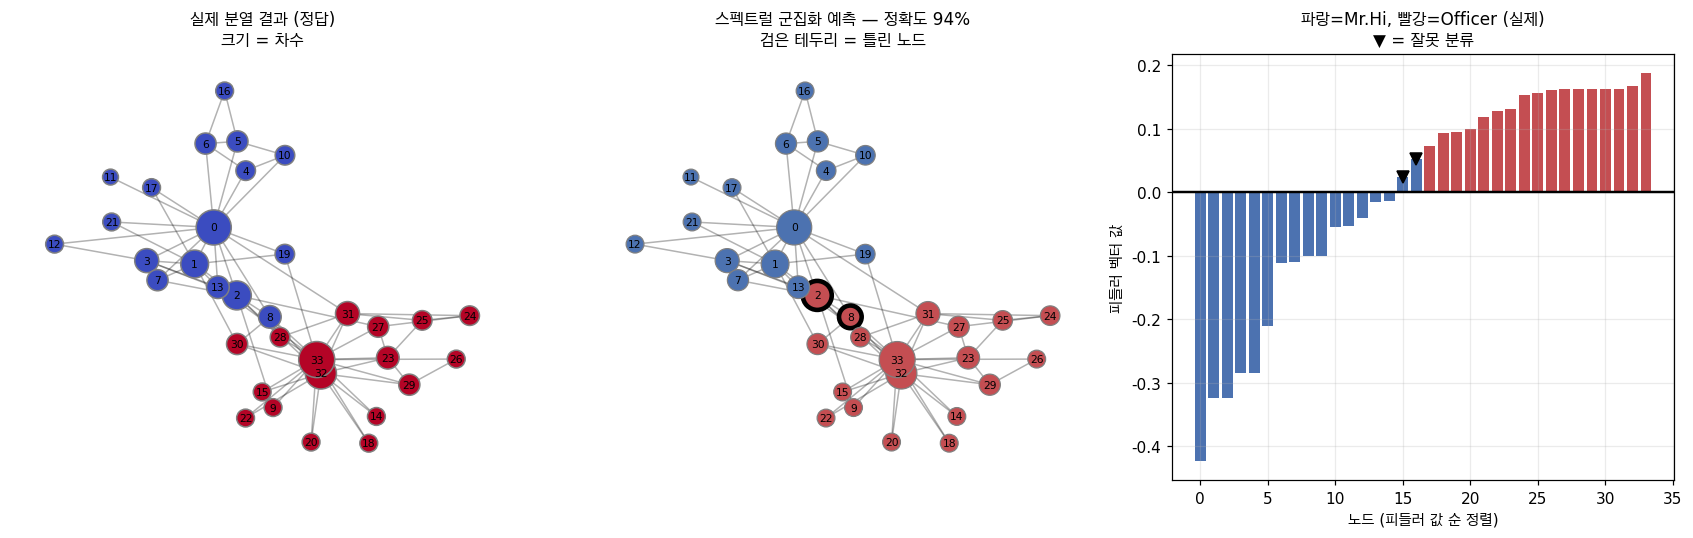

오른쪽 막대그래프가 핵심입니다.
0선을 기준으로 왼쪽은 거의 다 파랑, 오른쪽은 거의 다 빨강입니다.
틀린 2개 노드([2, 8])는 0 근처, 즉 '경계에 걸친 사람들'입니다.
양쪽에 친구가 고루 있어서 어디로 갈지 애매했던 사람들이죠.

⚠️ 참고: 이 데이터셋은 엣지에 weight 속성이 붙어 있습니다.
   가중치를 쓰면 정확도가 조금 더 오르지만, 원문이 다루는 '78개 엣지'와 맞추려면
   weight=None으로 0/1 행렬을 써야 합니다. 위에서 그렇게 했습니다.


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5))
pos_k = nx.spring_layout(G_k, seed=42)

# (1) 실제 분열
nx.draw_networkx_edges(G_k, pos_k, ax=axes[0], alpha=0.3)
nx.draw_networkx_nodes(G_k, pos_k, ax=axes[0], node_color=truth_k, cmap="coolwarm",
                       node_size=[80 + 28*d for d in deg_k], edgecolors="gray")
nx.draw_networkx_labels(G_k, pos_k, ax=axes[0], font_size=7)
axes[0].set_title("실제 분열 결과 (정답)\n크기 = 차수", fontsize=11)
axes[0].axis("off")

# (2) 스펙트럴 군집화 결과
node_colors = ["#4c72b0" if l == 0 else "#c44e52" for l in labels_k]
edge_cols = ["black" if i in wrong else "gray" for i in range(n_k)]
lw = [3.0 if i in wrong else 0.8 for i in range(n_k)]
nx.draw_networkx_edges(G_k, pos_k, ax=axes[1], alpha=0.3)
nx.draw_networkx_nodes(G_k, pos_k, ax=axes[1], node_color=node_colors,
                       node_size=[80 + 28*d for d in deg_k],
                       edgecolors=edge_cols, linewidths=lw)
nx.draw_networkx_labels(G_k, pos_k, ax=axes[1], font_size=7)
axes[1].set_title(f"스펙트럴 군집화 예측 — 정확도 {acc_k:.0%}\n검은 테두리 = 틀린 노드", fontsize=11)
axes[1].axis("off")

# (3) 피들러 벡터 값
order = np.argsort(fvec_k)
colors_sorted = ["#4c72b0" if truth_k[i] == 0 else "#c44e52" for i in order]
axes[2].bar(range(n_k), fvec_k[order], color=colors_sorted)
axes[2].axhline(0, color="black", lw=1.6)
for rank_pos, i in enumerate(order):
    if i in wrong:
        axes[2].plot(rank_pos, fvec_k[i], "kv", ms=8)
axes[2].set_xlabel("노드 (피들러 값 순 정렬)"); axes[2].set_ylabel("피들러 벡터 값")
axes[2].set_title("파랑=Mr.Hi, 빨강=Officer (실제)\n▼ = 잘못 분류", fontsize=11)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 막대그래프가 핵심입니다.")
print("0선을 기준으로 왼쪽은 거의 다 파랑, 오른쪽은 거의 다 빨강입니다.")
print(f"틀린 {len(wrong)}개 노드({list(wrong)})는 0 근처, 즉 '경계에 걸친 사람들'입니다.")
print("양쪽에 친구가 고루 있어서 어디로 갈지 애매했던 사람들이죠.")
print("\n⚠️ 참고: 이 데이터셋은 엣지에 weight 속성이 붙어 있습니다.")
print("   가중치를 쓰면 정확도가 조금 더 오르지만, 원문이 다루는 '78개 엣지'와 맞추려면")
print("   weight=None으로 0/1 행렬을 써야 합니다. 위에서 그렇게 했습니다.")

## 1️⃣1️⃣ 📝 연습문제 (풀이 포함)

1. **PageRank 밑바닥 구현** — 균등 점수에서 시작해 `d=0.85`로 수렴까지 반복. *(→ 9절에서 완료)*
2. **스펙트럴 군집화로 커뮤니티 찾기** — 두 클리크를 엣지로 이어 놓고 분할. 다리를 늘리면? *(→ 6절에서 완료)*
3. **다익스트라 구현** — 가중 그래프의 최단 경로. 균등 가중치일 때 BFS와 비교.
4. **2층 메시지 패싱** — 두 번 적용해 2-hop 정보가 도달함을 보이기.
5. **Karate Club 분석** — 차수 분포·라플라시안 고유값·스펙트럴 군집화를 정답과 비교. *(→ 10절에서 완료)*

In [21]:
print("=" * 74)
print("연습 3 — 다익스트라 알고리즘")
print("=" * 74)
import heapq

def dijkstra(graph, start):
    dist = {i: math.inf for i in range(graph.n)}
    dist[start] = 0.0
    prev = {start: None}
    pq = [(0.0, start)]
    visited = set()
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        for v, w in graph.adj[u].items():
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                prev[v] = u
                heapq.heappush(pq, (nd, v))
    return dist, prev

# 가중 그래프
gw = Graph(6)
for u, v, w in [(0,1,4), (0,2,1), (2,1,2), (1,3,5), (2,3,8), (3,4,3), (2,4,10), (4,5,1)]:
    gw.add_edge(u, v, w)

dist_w, prev_w = dijkstra(gw, 0)
print("가중 그래프에서 0번 노드로부터의 최단 거리\n")
print(f"{'노드':>6}{'다익스트라':>14}{'networkx':>14}{'경로':>22}")
print("-" * 58)
Gw_nx = nx.Graph()
for u in range(gw.n):
    for v, w in gw.adj[u].items():
        Gw_nx.add_edge(u, v, weight=w)
nx_d = nx.single_source_dijkstra_path_length(Gw_nx, 0)
for i in range(gw.n):
    path, cur = [], i
    while cur is not None:
        path.append(cur); cur = prev_w.get(cur)
    print(f"{i:>6}{dist_w[i]:>14.1f}{nx_d[i]:>14.1f}{' → '.join(map(str, reversed(path))):>22}")

print("\n[균등 가중치라면 BFS와 같은 답이 나와야 합니다]")
gu = Graph(6)
for u, v, _ in [(0,1,4), (0,2,1), (2,1,2), (1,3,5), (2,3,8), (3,4,3), (2,4,10), (4,5,1)]:
    gu.add_edge(u, v, 1.0)
d_dij, _ = dijkstra(gu, 0)
_, d_bfs = bfs(gu, 0)
print(f"  다익스트라: {[d_dij[i] for i in range(6)]}")
print(f"  BFS       : {[d_bfs[i] for i in range(6)]}")
print(f"  일치? {all(d_dij[i] == d_bfs[i] for i in range(6))} ✓")
print("\n  => 가중치가 모두 같으면 BFS로 충분합니다 (더 빠르고요).")
print("     가중치가 다를 때만 다익스트라가 필요합니다.")
print("     ⚠️ 위 가중 그래프에서 0→1은 직접 가면 4, 2를 거치면 1+2=3입니다.")
print("        BFS는 '홉 수'만 세므로 이런 경우를 못 잡습니다.")

연습 3 — 다익스트라 알고리즘
가중 그래프에서 0번 노드로부터의 최단 거리

    노드         다익스트라      networkx                    경로
----------------------------------------------------------
     0           0.0           0.0                     0
     1           3.0           3.0             0 → 2 → 1
     2           1.0           1.0                 0 → 2
     3           8.0           8.0         0 → 2 → 1 → 3
     4          11.0          11.0             0 → 2 → 4
     5          12.0          12.0         0 → 2 → 4 → 5

[균등 가중치라면 BFS와 같은 답이 나와야 합니다]
  다익스트라: [0.0, 1.0, 1.0, 2.0, 2.0, 3.0]
  BFS       : [0, 1, 1, 2, 2, 3]
  일치? True ✓

  => 가중치가 모두 같으면 BFS로 충분합니다 (더 빠르고요).
     가중치가 다를 때만 다익스트라가 필요합니다.
     ⚠️ 위 가중 그래프에서 0→1은 직접 가면 4, 2를 거치면 1+2=3입니다.
        BFS는 '홉 수'만 세므로 이런 경우를 못 잡습니다.


In [22]:
print("=" * 74)
print("연습 4 — 2층 메시지 패싱과 2-hop 정보")
print("=" * 74)

# 별 모양 두 개를 이은 그래프: 0-1-2 ... 특정 노드가 2홉 떨어지도록
g2h = Graph(7)
for u, v in [(0,1), (1,2), (2,3), (3,4), (0,5), (5,6)]:
    g2h.add_edge(u, v)
A2 = g2h.adjacency_matrix()
A2n = normalize_adjacency(A2, add_self_loops=True, symmetric=True)

rng = np.random.default_rng(11)
H0 = rng.normal(size=(7, 3))
W1 = rng.normal(size=(3, 4)) * 0.5
W2 = rng.normal(size=(4, 2)) * 0.5
relu = lambda z: np.maximum(z, 0)

H1 = message_passing(A2n, H0, W1, relu)
H2 = message_passing(A2n, H1, W2, relu)

print(f"그래프: 4-3-2-1-0-5-6  (일자 경로)")
print(f"  입력 특징 {H0.shape} -> 1층 {H1.shape} -> 2층 {H2.shape}\n")

# 노드 4의 특징을 바꾸면 어느 노드까지 영향이 가는가
def influence(n_layers, source=4):
    H = np.zeros((7, 1))
    A_use = normalize_adjacency(A2, add_self_loops=True, symmetric=True)
    H[source, 0] = 1.0
    for _ in range(n_layers):
        H = A_use @ H
    return H[:, 0]

print("노드 4의 정보가 몇 층 만에 어디까지 도달하나 (경로: 4-3-2-1-0-5-6)")
print(f"{'층':>4}  " + "".join(f"{i:>10}" for i in range(7)))
print("-" * 78)
for k in range(1, 5):
    inf = influence(k)
    print(f"{k:>4}  " + "".join(f"{v:>10.4f}" for v in inf)
          + f"   도달 {int(np.sum(inf > 1e-12))}개")

print("\n=> 1층: 노드 4와 그 직접 이웃(3)까지")
print("   2층: 노드 2까지 (2-hop 이웃)")
print("   K층: K-hop 이웃까지")
print("\n   💡 그래서 GNN의 층 수는 '얼마나 먼 이웃까지 볼 것인가'를 정하는 하이퍼파라미터입니다.")
print("      다만 8절에서 봤듯 무작정 늘리면 과도한 평활화가 옵니다.")

연습 4 — 2층 메시지 패싱과 2-hop 정보
그래프: 4-3-2-1-0-5-6  (일자 경로)
  입력 특징 (7, 3) -> 1층 (7, 4) -> 2층 (7, 2)

노드 4의 정보가 몇 층 만에 어디까지 도달하나 (경로: 4-3-2-1-0-5-6)
   층           0         1         2         3         4         5         6
------------------------------------------------------------------------------
   1      0.0000    0.0000    0.0000    0.4082    0.5000    0.0000    0.0000   도달 2개
   2      0.0000    0.0000    0.1361    0.3402    0.4167    0.0000    0.0000   도달 3개
   3      0.0000    0.0454    0.1588    0.3289    0.3472    0.0000    0.0000   도달 4개
   4      0.0151    0.0680    0.1777    0.3043    0.3079    0.0000    0.0000   도달 5개

=> 1층: 노드 4와 그 직접 이웃(3)까지
   2층: 노드 2까지 (2-hop 이웃)
   K층: K-hop 이웃까지

   💡 그래서 GNN의 층 수는 '얼마나 먼 이웃까지 볼 것인가'를 정하는 하이퍼파라미터입니다.
      다만 8절에서 봤듯 무작정 늘리면 과도한 평활화가 옵니다.


## 1️⃣2️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **그래프** | "노드와 엣지" | 쌍별 관계를 인코딩하는 수학 구조 `G=(V,E)` |
| **인접 행렬** | "연결 표" | `A[i][j]=1`이면 `i`와 `j`가 연결. **`A^k`는 길이 k 경로의 개수** |
| **차수** | "얼마나 연결되어 있나" | 노드에 붙은 엣지의 수. 분포가 네트워크 종류를 드러냅니다 |
| **라플라시안** | "D 빼기 A" | `L = D − A`. **`xᵀLx = Σ(xᵢ−xⱼ)²`** — 이웃과의 차이를 재는 연산자 |
| **피들러 값** | "대수적 연결도" | `L`의 가장 작은 0 아닌 고유값. 그래프를 자르기가 얼마나 어려운가 |
| **피들러 벡터** | "최적 분할선" | 피들러 값의 고유벡터. **부호로 두 그룹이 갈립니다** |
| **BFS** | "레벨별 탐색" | 큐 기반. **비가중 그래프의 최단 경로**를 찾습니다 |
| **DFS** | "깊게 먼저" | 스택 기반. 연결 성분·사이클·위상 정렬에 씁니다 |
| **메시지 패싱** | "이웃과 대화하기" | 이웃 특징을 모아 자기를 갱신. **`ÂHW`라는 행렬 곱**입니다 |
| **스펙트럴 군집화** | "고유벡터로 군집화" | 라플라시안 고유벡터로 그래프 분할. 반복 최적화 없이 한 번에 |
| **연결 성분** | "떨어진 조각" | 서로 도달 가능한 최대 부분그래프. **0 고유값의 개수와 같습니다** |
| **과도한 평활화** | "층을 너무 쌓으면 망함" | 반복 전파가 상수 벡터로 수렴해 노드 구분이 사라지는 현상 |
| **PageRank** | "구글 알고리즘" | 랜덤 서퍼의 정상 분포. 노드 중요도 척도 |

---

## 🎯 한 문장 정리

> **그래프를 행렬로 바꾸는 순간, 그래프 문제가 선형대수 문제가 됩니다.
> 그리고 라플라시안의 고유값·고유벡터 안에 구조가 전부 들어 있습니다.**

| 알고 싶은 것 | 탐색으로 | 스펙트럼으로 |
| --- | --- | --- |
| 연결 성분 개수 | BFS/DFS 반복 | **0인 고유값 세기** |
| 자연스러운 2분할 | (조합 최적화, 어려움) | **피들러 벡터 부호** |
| 얼마나 튼튼히 연결됐나 | (직관적 판단) | **피들러 값** |
| 노드 중요도 | 차수 세기 | **PageRank(정상 분포)** |
| K-hop 정보 모으기 | K중 for 루프 | **`Â^K H`** |

그리고 GNN은 마지막 줄입니다. **`H ← σ(ÂHW)`** — 이 한 줄이 GCN 층의 전부이고,
`Â = D̂^(-1/2)ÂD̂^(-1/2) = I − L_sym` 이라 결국 **라플라시안 이야기**입니다.

---

## 📖 더 읽을거리

- **Kipf & Welling (2017)** — [Semi-Supervised Classification with Graph Convolutional Networks](https://arxiv.org/abs/1609.02907). 현대 GNN을 연 논문
- **Spielman (2012)** — Spectral Graph Theory 강의 노트. 라플라시안·스펙트럴 갭·그래프 분할의 정본
- **Hamilton (2020)** — [Graph Representation Learning](https://www.cs.mcgill.ca/~wlh/grl_book/). GNN 기초부터 응용까지
- **Veličković et al. (2018)** — [Graph Attention Networks](https://arxiv.org/abs/1710.10903). 메시지 패싱에 어텐션을 결합
- **Bronstein et al. (2021)** — [Geometric Deep Learning](https://arxiv.org/abs/2104.13478). 통합 프레임워크 논문